# Topology-Fused Brain Tumor Pipeline (Final Full Notebook)

This is the **fully expanded Kaggle notebook version** of the upgraded pipeline. It is self-contained and includes the actual code cells for:

- multi-scale TDA features
- TDA-weighted Tucker decomposition
- tensor-network comparison (TT / TR)
- CNN baseline with topology-aware regularization
- explainability alignment with Dice/IoU
- optional cross-dataset evaluation
- ablation study and saved plots/metrics

Recommended runtime: **Kaggle P100 GPU**


In [2]:
!ls /kaggle/input/datasets/usable1234/brain-tumor-dataset-apr-7

Dataset


In [3]:
!ls /kaggle/input/datasets/usable1234/brain-tumor-dataset-apr-7/Dataset

Testing  Training


In [4]:
!ls /kaggle/input/datasets/usable1234/brain-tumor-dataset-apr-7/Dataset/Testing
!ls /kaggle/input/datasets/usable1234/brain-tumor-dataset-apr-7/Dataset/Training

glioma	meningioma  notumor  pituitary
glioma	meningioma  notumor  pituitary


In [5]:
import importlib
import subprocess
import sys

MODULE_TO_PACKAGE = {
    'ripser': 'ripser',
    'persim': 'persim',
    'tensorly': 'tensorly',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'lime': 'lime',
    'cv2': 'opencv-python',
    'skimage': 'scikit-image',
}

missing = []
for module_name, package_name in MODULE_TO_PACKAGE.items():
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(package_name)

if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('All required packages are already installed.')


Installing: ['ripser', 'persim', 'tensorly']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 96.4 MB/s eta 0:00:00


## 2. Configure dataset paths

If needed, change `PRIMARY_DATASET_BASE`.

For optional cross-dataset generalization, set `SECONDARY_DATASET_BASE` to another dataset with `Training/` and `Testing/` directories matching the same class names.


In [6]:
import os
from pathlib import Path

# Prefer your Kaggle dataset first. The pipeline expects the dataset root
# to contain Training/ and Testing/ folders directly.
CANDIDATE_PRIMARY_DATASETS = [
    '/kaggle/input/datasets/usable1234/brain-tumor-dataset-apr-7/Dataset',
    '/kaggle/input/brainfinal/Dataset',
    '/kaggle/input/brain-tumor-mri-dataset',
    '/kaggle/input/brain-tumor-classification-mri',
    '/kaggle/input/brain-tumor-mri',
    '/kaggle/input/brain-tumor-dataset',
]

def _normalize_dataset_root(path_str):
    """Return the folder that directly contains Training/ and Testing/."""
    if not path_str:
        return None
    p = Path(path_str)
    if not p.exists():
        return None

    if (p / 'Training').exists() and (p / 'Testing').exists():
        return str(p)

    if (p / 'Dataset' / 'Training').exists() and (p / 'Dataset' / 'Testing').exists():
        return str(p / 'Dataset')

    return None

PRIMARY_DATASET_BASE = None
for candidate in CANDIDATE_PRIMARY_DATASETS:
    resolved = _normalize_dataset_root(candidate)
    if resolved is not None:
        PRIMARY_DATASET_BASE = resolved
        break

# Fallback: scan /kaggle/input for any dataset that matches the expected structure.
if PRIMARY_DATASET_BASE is None:
    for dataset_root in Path('/kaggle/input').glob('*'):
        resolved = _normalize_dataset_root(dataset_root)
        if resolved is not None:
            PRIMARY_DATASET_BASE = resolved
            break
        for nested in dataset_root.glob('*'):
            resolved = _normalize_dataset_root(nested)
            if resolved is not None:
                PRIMARY_DATASET_BASE = resolved
                break
        if PRIMARY_DATASET_BASE is not None:
            break

SECONDARY_DATASET_BASE = None
SECONDARY_DATASET_NAME = 'secondary'
OUTPUT_DIR = '/kaggle/working/output'
CNN_EPOCHS = 8

assert PRIMARY_DATASET_BASE is not None, (
    'Could not find a valid dataset root. Expected Training/ and Testing/ folders '
    'either directly inside the dataset path or inside a Dataset/ subfolder.'
)

os.environ['BRAIN_TUMOR_DATASET_BASE'] = PRIMARY_DATASET_BASE
os.environ['BRAIN_TUMOR_OUTPUT_DIR'] = OUTPUT_DIR
os.environ['BRAIN_TUMOR_CNN_EPOCHS'] = str(CNN_EPOCHS)

if SECONDARY_DATASET_BASE:
    os.environ['BRAIN_TUMOR_SECONDARY_DATASET_BASE'] = SECONDARY_DATASET_BASE
    os.environ['BRAIN_TUMOR_SECONDARY_DATASET_NAME'] = SECONDARY_DATASET_NAME

print('Primary dataset:', PRIMARY_DATASET_BASE)
print('Secondary dataset:', SECONDARY_DATASET_BASE)
print('Output dir:', OUTPUT_DIR)
print('CNN epochs:', CNN_EPOCHS)
print('Train classes:', sorted(os.listdir(os.path.join(PRIMARY_DATASET_BASE, 'Training'))))
print('Test classes:', sorted(os.listdir(os.path.join(PRIMARY_DATASET_BASE, 'Testing'))))


Primary dataset: /kaggle/input/datasets/usable1234/brain-tumor-dataset-apr-7/Dataset
Secondary dataset: None
Output dir: /kaggle/working/output
CNN epochs: 8
Train classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 3. Configuration

In [7]:
"""
Configuration for Topology-Fused Tensor Learning Pipeline
=========================================================
All hyperparameters, paths, and settings in one place.
Optimized for Kaggle P100 GPU environment.
"""

import os

_CONFIG_FILE = globals().get('__file__', os.path.join(os.getcwd(), 'training', 'config.py'))
TRAINING_DIR = os.path.dirname(os.path.abspath(_CONFIG_FILE))
PROJECT_ROOT = os.path.dirname(TRAINING_DIR)
DEFAULT_LOCAL_DATASET_BASE = os.path.join(PROJECT_ROOT, 'data', 'Dataset')
DEFAULT_LOCAL_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'training_output')

# =============================================================================
# PATHS — Update DATASET_BASE for your Kaggle environment
# =============================================================================
DATASET_BASE = os.environ.get('BRAIN_TUMOR_DATASET_BASE', '/kaggle/input/datasets/akkinenisaimanasa/brainfinal/Dataset')
if not os.path.exists(DATASET_BASE) and os.path.exists(DEFAULT_LOCAL_DATASET_BASE):
    DATASET_BASE = DEFAULT_LOCAL_DATASET_BASE

if os.path.exists(os.path.join(DATASET_BASE, 'Dataset', 'Training')) and os.path.exists(os.path.join(DATASET_BASE, 'Dataset', 'Testing')):
    DATASET_BASE = os.path.join(DATASET_BASE, 'Dataset')

PATH_TRAIN = os.path.join(DATASET_BASE, 'Training')
PATH_TEST = os.path.join(DATASET_BASE, 'Testing')

OUTPUT_DIR = os.environ.get('BRAIN_TUMOR_OUTPUT_DIR', '/kaggle/working/output')
if OUTPUT_DIR.startswith('/kaggle/') and not os.path.exists('/kaggle'):
    OUTPUT_DIR = DEFAULT_LOCAL_OUTPUT_DIR

SECONDARY_DATASET_BASE = os.environ.get('BRAIN_TUMOR_SECONDARY_DATASET_BASE')
SECONDARY_PATH_TRAIN = (
    os.path.join(SECONDARY_DATASET_BASE, 'Training') if SECONDARY_DATASET_BASE else None
)
SECONDARY_PATH_TEST = (
    os.path.join(SECONDARY_DATASET_BASE, 'Testing') if SECONDARY_DATASET_BASE else None
)
ENABLE_CROSS_DATASET_GENERALIZATION = True
CROSS_DATASET_SPLIT = 'test'
CROSS_DATASET_NAME = os.environ.get('BRAIN_TUMOR_SECONDARY_DATASET_NAME', 'secondary')

LABELS = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(LABELS)
IMG_SIZE = 250

# =============================================================================
# PREPROCESSING
# =============================================================================
GAUSSIAN_BLUR_KERNEL = (5, 5)
CONTRAST_ALPHA = 1.5
CONTRAST_BETA = 80

# =============================================================================
# TDA — MULTI-SCALE PERSISTENT HOMOLOGY (Novel Contribution #1)
# =============================================================================
# Multiple smoothing scales to capture fine texture AND gross structure
TDA_SCALES = [5, 10, 20, 40]         # Window sizes for multi-scale persistence
TDA_BORDER_WIDTHS = [35, 70]          # Border widths per scale
TDA_MAX_HOMOLOGY_DIM = 1             # 0=components, 1=loops/holes (Novel: H1)
TDA_PARAM_MASK = 0.5                 # ROI mask weighting for non-ROI pixels

# Persistence feature extraction settings
PERSISTENCE_NUM_LANDSCAPES = 5        # Number of persistence landscape functions
PERSISTENCE_LANDSCAPE_RESOLUTION = 100  # Grid resolution for landscapes
PERSISTENCE_IMAGE_RESOLUTION = 20     # Pixels per side for persistence images
PERSISTENCE_IMAGE_SIGMA = 0.1        # Bandwidth for persistence images
BETTI_CURVE_RESOLUTION = 100         # Grid resolution for Betti curves

# =============================================================================
# TUCKER DECOMPOSITION
# =============================================================================
# Standard Tucker ranks to evaluate
TUCKER_RANKS = [10, 20, 30, 40, 50]
TUCKER_DEFAULT_RANK = (30, 30, 300)   # (R1, R2, R3) — R3 auto-set to n_samples

# TDA-Weighted Tucker (Novel Contribution #2)
TDA_WEIGHTED_TUCKER = True            # Enable topology-guided tensor decomposition
TDA_WEIGHT_ALPHA = 2.0               # Weight multiplier for ROI pixels
TDA_WEIGHT_BACKGROUND = 0.5          # Weight for non-ROI pixels

# Tensor-network alternatives (Novel Contribution #6)
ENABLE_TENSOR_NETWORK_EVAL = False
TT_RANKS = [[1, 20, 20, 1], [1, 30, 30, 1], [1, 40, 40, 1]]
TR_RING_RANKS = [10, 16, 24]
TENSOR_NETWORK_FUSION_PCA = 0.99

# =============================================================================
# FEATURE FUSION (Novel Contribution #3)
# =============================================================================
FUSION_METHOD = 'concatenate'         # 'concatenate' or 'weighted'
FUSION_NORMALIZE = True               # StandardScaler before fusion
FUSION_PCA_VARIANCE = 0.99           # PCA on fused features (preserve more info)

# =============================================================================
# CNN BASELINE + TOPOLOGICAL REGULARIZATION
# =============================================================================
ENABLE_CNN_BASELINE = True
CNN_BATCH_SIZE = 32
CNN_EPOCHS = int(os.environ.get('BRAIN_TUMOR_CNN_EPOCHS', 8))
CNN_LEARNING_RATE = 1e-3
CNN_WEIGHT_DECAY = 1e-4
CNN_EMBED_DIM = 128
CNN_DROPOUT = 0.30
ENABLE_TOPOLOGICAL_REGULARIZATION = True
TOPO_REG_LAMBDA = 0.15
TOPO_REG_PAIRWISE_SAMPLES = 16
CNN_EXPLAINABILITY_METHODS = ['gradcam', 'saliency', 'shap', 'lime']
EXPLAINABILITY_THRESHOLD_PERCENTILE = 85
EXPLAINABILITY_MAX_SAMPLES = 128

# =============================================================================
# CLASSIFIERS & HYPERPARAMETER TUNING
# =============================================================================
NUM_ITERATIONS = 5                    # Repeated evaluations for mean/std
CV_FOLDS = 5                         # Stratified K-Fold for cross-validation
RANDOM_STATE = 42

# Hyperparameter grids for GridSearchCV
HYPERPARAM_GRIDS = {
    "Extra Trees": {
        'n_estimators': [200, 300, 500],
        'max_depth': [None, 30, 50],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2'],
    },
    "Random Forest": {
        'n_estimators': [200, 300, 500],
        'max_depth': [None, 30, 50],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 'log2'],
    },
    "XGBoost": {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    },
    "SVM": {
        'C': [0.1, 1, 10, 100],
        'kernel': ['rbf', 'poly'],
        'gamma': ['scale', 'auto'],
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
    },
    "LightGBM": {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8, -1],
        'learning_rate': [0.05, 0.1, 0.2],
        'num_leaves': [31, 63, 127],
    },
}

# XGBoost GPU settings for Kaggle P100
XGBOOST_GPU_PARAMS = {
    'tree_method': 'hist',
    'device': 'cuda',
    'objective': 'multi:softprob',
    'num_class': NUM_CLASSES,
    'eval_metric': 'mlogloss',
    'n_jobs': -1,
}

# =============================================================================
# ABLATION STUDY CONFIGURATIONS
# =============================================================================
ABLATION_CONFIGS = {
    'baseline_raw': {
        'use_tucker': False, 'use_tda_features': False, 'use_tda_weighted_tucker': False,
        'description': 'Raw flattened pixels (baseline)'
    },
    'tucker_only': {
        'use_tucker': True, 'use_tda_features': False, 'use_tda_weighted_tucker': False,
        'description': 'Standard Tucker decomposition only (original paper)'
    },
    'tda_features_only': {
        'use_tucker': False, 'use_tda_features': True, 'use_tda_weighted_tucker': False,
        'description': 'TDA persistence features only'
    },
    'tucker_plus_tda': {
        'use_tucker': True, 'use_tda_features': True, 'use_tda_weighted_tucker': False,
        'description': 'Standard Tucker + TDA features fused'
    },
    'weighted_tucker_plus_tda': {
        'use_tucker': True, 'use_tda_features': True, 'use_tda_weighted_tucker': True,
        'description': 'TDA-weighted Tucker + TDA features (FULL NOVEL PIPELINE)'
    },
}

## 4. Data loading and preprocessing

In [8]:
"""
Data Loading & Preprocessing Module
====================================
Handles image loading, preprocessing, negative transform, normalization.
Compatible with Kaggle P100 environment.
"""

import os
import numpy as np
import cv2
from tqdm import tqdm


def dataset_split_exists(dataset_path, labels=LABELS):
    """Return True when a dataset split exists and contains at least one label dir."""
    if not dataset_path or not os.path.exists(dataset_path):
        return False
    return any(os.path.isdir(os.path.join(dataset_path, label)) for label in labels)


def resolve_dataset_paths(train_path=None, test_path=None):
    """Resolve dataset split paths, defaulting to the configured primary dataset."""
    train_path = train_path or PATH_TRAIN
    test_path = test_path or PATH_TEST
    return train_path, test_path


def get_secondary_dataset_paths():
    """Return configured secondary dataset paths when available."""
    if dataset_split_exists(SECONDARY_PATH_TRAIN) or dataset_split_exists(SECONDARY_PATH_TEST):
        return SECONDARY_PATH_TRAIN, SECONDARY_PATH_TEST
    return None, None


def import_data(dataset_path, labels=LABELS, image_size=IMG_SIZE, preprocess=True):
    """
    Load images from folder structure with optional preprocessing.

    Parameters
    ----------
    dataset_path : str
        Path to dataset split (Training or Testing)
    labels : list
        Class label folder names
    image_size : int
        Target image size (square)
    preprocess : bool
        If True, apply Gaussian blur and contrast enhancement

    Returns
    -------
    images : list of ndarray
        Loaded (and optionally preprocessed) grayscale images
    image_labels : list of int
        Integer labels corresponding to each image
    """
    images = []
    image_labels = []

    for label_idx, label in enumerate(labels):
        label_path = os.path.join(dataset_path, label)
        if not os.path.exists(label_path):
            print(f"Warning: {label_path} does not exist, skipping.")
            continue

        files = sorted(os.listdir(label_path))
        print(f"Loading {label}: {len(files)} images...")

        for filename in tqdm(files, desc=f"  {label}", leave=False):
            filepath = os.path.join(label_path, filename)
            try:
                image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    continue

                if preprocess:
                    image = cv2.GaussianBlur(image, GAUSSIAN_BLUR_KERNEL, 0)
                    image = cv2.convertScaleAbs(image, alpha=CONTRAST_ALPHA, beta=CONTRAST_BETA)

                image = cv2.resize(image, (image_size, image_size))
                images.append(image)
                image_labels.append(label_idx)
            except Exception as e:
                print(f"Error loading {filepath}: {e}")

    return images, image_labels


def data_to_negative(images):
    """Invert pixel values (negative transform)."""
    return [255 - img for img in images]


def preprocess_pipeline(path_train, path_test):
    """
    Full preprocessing pipeline: load, negative, normalize.

    Returns
    -------
    x_train, y_train, x_test, y_test : ndarray
        Preprocessed image arrays and labels
    x_train_raw, x_test_raw : list
        Raw (non-negative) preprocessed images for TDA ROI overlay
    """
    print("=" * 60)
    print("Loading Training Data...")
    print("=" * 60)
    x_train, y_train = import_data(path_train, preprocess=True)

    print(f"\n{'=' * 60}")
    print("Loading Testing Data...")
    print("=" * 60)
    x_test, y_test = import_data(path_test, preprocess=True)

    # Also load without preprocessing for ROI visualization
    print(f"\n{'=' * 60}")
    print("Loading raw images for ROI overlay...")
    print("=" * 60)
    x_train_raw, _ = import_data(path_train, preprocess=False)
    x_test_raw, _ = import_data(path_test, preprocess=False)

    print(f"\nTotal training samples: {len(x_train)}")
    print(f"Total testing samples: {len(x_test)}")

    # Negative transform
    x_train_neg = data_to_negative(x_train)
    x_test_neg = data_to_negative(x_test)

    # Normalize to [0, 1]
    x_train_norm = np.array(x_train_neg) / 255.0
    x_test_norm = np.array(x_test_neg) / 255.0

    y_train = np.array(y_train)
    y_test = np.array(y_test)

    return x_train_norm, y_train, x_test_norm, y_test, x_train_raw, x_test_raw


def preprocess_external_dataset(path_train=None, path_test=None):
    """
    Load and preprocess a secondary dataset with the same folder layout.

    Returns None if neither split exists.
    """
    if path_train is None and path_test is None:
        return None

    has_train = dataset_split_exists(path_train)
    has_test = dataset_split_exists(path_test)

    if not has_train and not has_test:
        return None

    datasets = {}
    if has_train:
        print(f"\n{'=' * 60}")
        print(f"Loading External Training Data: {path_train}")
        print("=" * 60)
        x_train, y_train = import_data(path_train, preprocess=True)
        datasets['train_images'] = np.array(data_to_negative(x_train)) / 255.0
        datasets['train_labels'] = np.array(y_train)

    if has_test:
        print(f"\n{'=' * 60}")
        print(f"Loading External Testing Data: {path_test}")
        print("=" * 60)
        x_test, y_test = import_data(path_test, preprocess=True)
        datasets['test_images'] = np.array(data_to_negative(x_test)) / 255.0
        datasets['test_labels'] = np.array(y_test)

    return datasets


def flatten_images(x_data):
    """Flatten 2D images to 1D feature vectors."""
    return np.vstack([img.flatten() for img in x_data])


## 5. TDA feature extraction and ROI discovery

In [9]:
"""
Novel TDA Feature Extraction Module
====================================
CORE NOVELTY: Multi-scale persistent homology with H0+H1 features,
persistence landscapes, Betti curves, persistence entropy, and
persistence images — all fused into the classification pipeline.

Novel Contributions Implemented:
1. Multi-scale persistence (multiple smoothing windows)
2. H1 (loops/holes) topological features via Rips complex
3. Persistence landscapes (vectorized topological summaries)
4. Betti curves (component/hole counts at each filtration level)
5. Persistence entropy (information-theoretic summary)
6. Persistence images (stable vectorized representations)
7. Birth/death statistics (mean, variance, max lifetime)
"""
!pip install ripser
import numpy as np
from scipy import ndimage, sparse
from scipy.sparse.csgraph import connected_components
from scipy.ndimage import distance_transform_edt
from ripser import lower_star_img, ripser
from tqdm import tqdm
import time



# =====================================================================
# LOW-LEVEL TDA UTILITIES (from original utilsTDA.py, cleaned up)
# =====================================================================

def img_to_sparseDM(img):
    """Compute sparse distance matrix from image for persistent homology."""
    m, n = img.shape
    idxs = np.arange(m * n).reshape((m, n))
    I = idxs.flatten()
    J = idxs.flatten()
    img = img.copy()
    img[img == -np.inf] = np.inf
    V = img.flatten()

    tidxs = np.ones((m + 2, n + 2), dtype=np.int64) * np.nan
    tidxs[1:-1, 1:-1] = idxs
    tD = np.ones_like(tidxs) * np.nan
    tD[1:-1, 1:-1] = img

    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            thisJ = np.roll(np.roll(tidxs, di, axis=0), dj, axis=1)
            thisD = np.roll(np.roll(tD, di, axis=0), dj, axis=1)
            thisD = np.maximum(thisD, tD)
            boundary = ~np.isnan(thisD)
            I = np.concatenate((I, tidxs[boundary].flatten()))
            J = np.concatenate((J, thisJ[boundary].flatten()))
            V = np.concatenate((V, thisD[boundary].flatten()))

    return sparse.coo_matrix((V, (I, J)), shape=(idxs.size, idxs.size))


def connected_components_img(img):
    """Identify connected components of an image."""
    m, n = img.shape
    component = connected_components(img_to_sparseDM(img), directed=False)[1].reshape((m, n))
    return component


def smoothen(img, window_size):
    """Apply uniform filter smoothing."""
    return ndimage.uniform_filter(img.astype("float"), size=window_size)


def add_border(img, border_width):
    """Add border with minimum value to image."""
    img = img.copy()
    border_value = np.min(img) - 1
    img[0:border_width, :] = border_value
    img[(img.shape[0] - border_width):img.shape[0], :] = border_value
    img[:, 0:border_width] = border_value
    img[:, (img.shape[1] - border_width):img.shape[1]] = border_value
    return img


def lifetimes_from_dgm(dgm, compute_tau=False):
    """Rotate persistence diagram to lifetime representation."""
    dgm_lifetimes = np.vstack([dgm[:, 0], dgm[:, 1] - dgm[:, 0]]).T

    if compute_tau:
        dgm_for_tau = np.delete(dgm_lifetimes.copy(),
                                np.where(dgm_lifetimes[:, 1] == np.inf)[0], axis=0)
        sorted_points = dgm_for_tau[:, 1].copy()
        sorted_points[::-1].sort()
        dist_to_next = np.delete(sorted_points, len(sorted_points) - 1) - np.delete(sorted_points, 0)
        most_distant_to_next = np.argmax(dist_to_next)
        tau = (sorted_points[most_distant_to_next] + sorted_points[most_distant_to_next + 1]) / 2
        return dgm_lifetimes, tau

    return dgm_lifetimes


# =====================================================================
# ROI EXTRACTION (from original, needed for TDA-weighted Tucker)
# =====================================================================

def topological_process_img(img, window_size=None, border_width=None):
    """
    Extract topological components (ROIs) from a single image.
    Returns component mask and processed image.
    """
    img = img.copy()
    if window_size is not None:
        img = smoothen(img, window_size=window_size)
    if border_width is not None:
        img = add_border(img, border_width=border_width)

    dgm = lower_star_img(img)
    dgm_lifetimes, tau = lifetimes_from_dgm(dgm, compute_tau=True)

    idxs = np.where(np.logical_and(tau < dgm_lifetimes[:, 1],
                                    dgm_lifetimes[:, 1] < np.inf))[0]
    idxs = np.flip(idxs[np.argsort(dgm[idxs, 0])])
    didxs = np.zeros(0).astype("int")

    img_components = np.zeros_like(img)
    dist = np.zeros([len(idxs), img.shape[0], img.shape[1]])
    nearest_value = np.zeros([len(idxs), img.shape[0], img.shape[1]])

    for i, idx in enumerate(idxs):
        bidx = np.argmin(np.abs(img - dgm[idx, 0]))
        didxs = np.append(didxs, np.argmin(np.abs(img - dgm[idx, 1])))

        img_temp = np.ones_like(img)
        img_temp[np.logical_or(img < dgm[idx, 0] - 0.01, dgm[idx, 1] - 0.01 < img)] = np.nan
        component_at_idx = connected_components_img(img_temp)
        del img_temp

        component_at_idx = component_at_idx == component_at_idx[bidx // img.shape[1], bidx % img.shape[1]]
        if i > 0:
            didxs_in_component = idxs[np.where([component_at_idx[didx // img.shape[1], didx % img.shape[1]]
                                                 for didx in didxs])[0]]
            if len(didxs_in_component) > 0:
                component_at_idx[img > np.min(dgm[didxs_in_component, 1]) - 0.1] = False

        img_components[component_at_idx] = 1

        img_temp = np.ones_like(img)
        img_temp[component_at_idx] = 0
        dist[i, :, :], nearest_neighbor_temp = distance_transform_edt(img_temp, return_indices=True)
        nearest_value[i, :, :] = img[nearest_neighbor_temp[0], nearest_neighbor_temp[1]]
        del img_temp, nearest_neighbor_temp

    return img_components


def extract_roi_masks(x_data, window_size=10, border_width=70):
    """Extract ROI binary masks for all images."""
    masks = []
    for i in tqdm(range(len(x_data)), desc="Extracting ROIs"):
        mask = topological_process_img(x_data[i], window_size=window_size,
                                        border_width=border_width)
        masks.append(mask)
    return masks


# =====================================================================
# NOVEL: MULTI-SCALE PERSISTENCE DIAGRAM COMPUTATION
# =====================================================================

def compute_h0_persistence(img, window_size=10, border_width=70):
    """
    Compute H0 (connected components) persistence diagram using lower-star filtration.
    """
    img_smooth = smoothen(img.copy(), window_size=window_size)
    img_bordered = add_border(img_smooth, border_width=border_width)
    dgm = lower_star_img(img_bordered)
    # Remove infinite death points for feature extraction
    finite_mask = np.isfinite(dgm[:, 1])
    return dgm[finite_mask]


def compute_h1_persistence(img, window_size=10, max_points=500):
    """
    Compute H1 (loops/holes) persistence using Rips complex on subsampled image.

    H1 captures ring-enhancing structures in gliomas and necrotic cores —
    biologically meaningful topological features.
    """
    img_smooth = smoothen(img.copy(), window_size=window_size)

    # Subsample for computational feasibility
    step = max(1, img_smooth.shape[0] // int(np.sqrt(max_points)))
    coords = []
    values = []
    for i in range(0, img_smooth.shape[0], step):
        for j in range(0, img_smooth.shape[1], step):
            if img_smooth[i, j] > np.percentile(img_smooth, 20):  # Skip dark background
                coords.append([i, j])
                values.append(img_smooth[i, j])

    if len(coords) < 10:
        return np.empty((0, 2))

    coords = np.array(coords, dtype=np.float64)
    values = np.array(values)

    # Normalize coordinates and combine with intensity
    coords_norm = coords / coords.max()
    values_norm = values / (values.max() + 1e-8)

    # Weighted point cloud: spatial + intensity
    point_cloud = np.column_stack([coords_norm, values_norm * 0.5])

    # Limit points for memory
    if len(point_cloud) > max_points:
        indices = np.random.choice(len(point_cloud), max_points, replace=False)
        point_cloud = point_cloud[indices]

    result = ripser(point_cloud, maxdim=1, thresh=2.0)
    dgm_h1 = result['dgms'][1]

    # Remove infinite death points
    if len(dgm_h1) > 0:
        finite_mask = np.isfinite(dgm_h1[:, 1])
        dgm_h1 = dgm_h1[finite_mask]

    return dgm_h1


def compute_multiscale_persistence(img, scales=None, border_widths=None):
    """
    NOVEL: Compute persistence diagrams at multiple scales.

    Each scale captures different topological features:
    - Small scales (5): fine texture, small lesions (pituitary)
    - Medium scales (10-20): moderate structures
    - Large scales (40): gross morphology, large diffuse masses (glioma)

    Returns dict with H0 and H1 diagrams at each scale.
    """
    if scales is None:
        scales = TDA_SCALES
    if border_widths is None:
        border_widths = TDA_BORDER_WIDTHS

    diagrams = {}
    for scale in scales:
        bw = border_widths[0] if scale <= 10 else border_widths[-1]

        # H0: connected components
        dgm_h0 = compute_h0_persistence(img, window_size=scale, border_width=bw)
        diagrams[f'h0_scale{scale}'] = dgm_h0

        # H1: loops/holes (Novel)
        if TDA_MAX_HOMOLOGY_DIM >= 1:
            dgm_h1 = compute_h1_persistence(img, window_size=scale)
            diagrams[f'h1_scale{scale}'] = dgm_h1

    return diagrams


# =====================================================================
# NOVEL: PERSISTENCE FEATURE VECTORIZATION
# =====================================================================

def persistence_statistics(dgm):
    """
    Compute statistical summaries from a persistence diagram.

    Returns: [n_points, mean_birth, std_birth, mean_death, std_death,
              mean_lifetime, std_lifetime, max_lifetime, total_persistence,
              persistence_entropy]
    """
    if len(dgm) == 0:
        return np.zeros(10)

    births = dgm[:, 0]
    deaths = dgm[:, 1]
    lifetimes = deaths - births

    # Persistence entropy
    lifetimes_pos = lifetimes[lifetimes > 0]
    if len(lifetimes_pos) > 0:
        total = np.sum(lifetimes_pos)
        probs = lifetimes_pos / total
        entropy = -np.sum(probs * np.log(probs + 1e-10))
    else:
        entropy = 0.0

    return np.array([
        len(dgm),                    # Number of topological features
        np.mean(births),             # Mean birth time
        np.std(births),              # Std birth time
        np.mean(deaths),             # Mean death time
        np.std(deaths),              # Std death time
        np.mean(lifetimes),          # Mean lifetime (persistence)
        np.std(lifetimes),           # Std lifetime
        np.max(lifetimes),           # Max lifetime (most persistent feature)
        np.sum(lifetimes),           # Total persistence
        entropy,                     # Persistence entropy
    ])


def persistence_landscape(dgm, num_landscapes=None, resolution=None):
    """
    Compute persistence landscape vectors.

    Persistence landscapes are stable vectorized summaries of persistence diagrams
    that live in a Banach space — enabling statistical analysis.

    Parameters
    ----------
    dgm : ndarray (K, 2)
        Persistence diagram
    num_landscapes : int
        Number of landscape functions to compute
    resolution : int
        Grid resolution

    Returns
    -------
    landscapes : ndarray (num_landscapes * resolution,)
        Flattened landscape vector
    """
    if num_landscapes is None:
        num_landscapes = PERSISTENCE_NUM_LANDSCAPES
    if resolution is None:
        resolution = PERSISTENCE_LANDSCAPE_RESOLUTION

    if len(dgm) == 0:
        return np.zeros(num_landscapes * resolution)

    births = dgm[:, 0]
    deaths = dgm[:, 1]

    t_min = np.min(births)
    t_max = np.max(deaths)
    t_grid = np.linspace(t_min, t_max, resolution)

    # Tent functions for each point
    tent_values = np.zeros((len(dgm), resolution))
    for i in range(len(dgm)):
        b, d = births[i], deaths[i]
        mid = (b + d) / 2.0
        for j, t in enumerate(t_grid):
            if b <= t <= mid:
                tent_values[i, j] = t - b
            elif mid < t <= d:
                tent_values[i, j] = d - t
            else:
                tent_values[i, j] = 0.0

    # k-th landscape = k-th largest tent value at each t
    landscapes = np.zeros((num_landscapes, resolution))
    for j in range(resolution):
        sorted_vals = np.sort(tent_values[:, j])[::-1]
        for k in range(min(num_landscapes, len(sorted_vals))):
            landscapes[k, j] = sorted_vals[k]

    return landscapes.flatten()


def betti_curve(dgm, resolution=None):
    """
    Compute Betti curve: count of features alive at each filtration level.

    The Betti curve captures how topological complexity changes across scales.
    """
    if resolution is None:
        resolution = BETTI_CURVE_RESOLUTION

    if len(dgm) == 0:
        return np.zeros(resolution)

    births = dgm[:, 0]
    deaths = dgm[:, 1]
    t_grid = np.linspace(np.min(births), np.max(deaths), resolution)

    curve = np.zeros(resolution)
    for j, t in enumerate(t_grid):
        curve[j] = np.sum((births <= t) & (deaths > t))

    return curve


def persistence_image(dgm, resolution=None, sigma=None):
    """
    Compute persistence image: a stable vectorized representation.

    Maps persistence diagram to a 2D image using Gaussian kernels,
    weighted by persistence (longer-lived features contribute more).
    """
    if resolution is None:
        resolution = PERSISTENCE_IMAGE_RESOLUTION
    if sigma is None:
        sigma = PERSISTENCE_IMAGE_SIGMA

    if len(dgm) == 0:
        return np.zeros(resolution * resolution)

    births = dgm[:, 0]
    lifetimes = dgm[:, 1] - dgm[:, 0]

    b_min, b_max = np.min(births), np.max(births)
    l_min, l_max = 0, np.max(lifetimes)

    if b_max == b_min:
        b_max = b_min + 1
    if l_max == l_min:
        l_max = l_min + 1

    b_grid = np.linspace(b_min, b_max, resolution)
    l_grid = np.linspace(l_min, l_max, resolution)

    img = np.zeros((resolution, resolution))
    for i in range(len(dgm)):
        b, l = births[i], lifetimes[i]
        # Weight by lifetime (persistent features matter more)
        weight = l / (l_max + 1e-8)
        for gi in range(resolution):
            for gj in range(resolution):
                dist_sq = ((b_grid[gi] - b) ** 2 + (l_grid[gj] - l) ** 2) / (2 * sigma ** 2)
                img[gi, gj] += weight * np.exp(-dist_sq)

    return img.flatten()


# =====================================================================
# MASTER FEATURE EXTRACTION FUNCTION
# =====================================================================

def extract_tda_features_single(img, scales=None):
    """
    Extract complete TDA feature vector for a single image.

    Combines multi-scale H0+H1 persistence with:
    - Statistical summaries (10 features per diagram)
    - Persistence landscapes (num_landscapes * resolution per diagram)
    - Betti curves (resolution per diagram)
    - Persistence images (resolution^2 per diagram)

    Returns
    -------
    features : ndarray
        Concatenated TDA feature vector
    """
    if scales is None:
        scales = TDA_SCALES

    diagrams = compute_multiscale_persistence(img, scales=scales)

    all_features = []

    for key, dgm in diagrams.items():
        # Statistical summaries (compact, always 10 features)
        stats = persistence_statistics(dgm)
        all_features.append(stats)

        # Persistence landscapes (stable, good for ML)
        landscapes = persistence_landscape(dgm)
        all_features.append(landscapes)

        # Betti curves (interpretable)
        bcurve = betti_curve(dgm)
        all_features.append(bcurve)

        # Persistence images (stable, dense representation)
        pimg = persistence_image(dgm)
        all_features.append(pimg)

    return np.concatenate(all_features)


def extract_tda_features_batch(x_data, scales=None):
    """
    Extract TDA features for an entire dataset.

    Parameters
    ----------
    x_data : ndarray (N, H, W)
        Normalized grayscale images

    Returns
    -------
    tda_features : ndarray (N, D_tda)
        TDA feature matrix
    """
    print("=" * 60)
    print("Extracting Multi-Scale TDA Features (H0 + H1)...")
    print(f"  Scales: {scales or TDA_SCALES}")
    print(f"  Max homology dim: {TDA_MAX_HOMOLOGY_DIM}")
    print("=" * 60)

    start_time = time.time()
    features = []

    for i in tqdm(range(len(x_data)), desc="TDA Features"):
        feat = extract_tda_features_single(x_data[i], scales=scales)
        features.append(feat)

    tda_features = np.array(features)
    elapsed = time.time() - start_time
    print(f"\nTDA feature extraction complete: {tda_features.shape}")
    print(f"  Features per image: {tda_features.shape[1]}")
    print(f"  Time: {elapsed:.1f}s ({elapsed/len(x_data):.2f}s per image)")

    return tda_features


def extract_tda_features_compact(x_data, scales=None):
    """
    FASTER version: only statistical summaries + Betti curves (no landscapes/images).
    Use this if full extraction is too slow.
    """
    if scales is None:
        scales = TDA_SCALES

    print("Extracting compact TDA features (stats + Betti curves only)...")
    start_time = time.time()
    features = []

    for i in tqdm(range(len(x_data)), desc="TDA Compact"):
        diagrams = compute_multiscale_persistence(x_data[i], scales=scales)
        feat_parts = []
        for key, dgm in diagrams.items():
            feat_parts.append(persistence_statistics(dgm))
            feat_parts.append(betti_curve(dgm))
        features.append(np.concatenate(feat_parts))

    tda_features = np.array(features)
    elapsed = time.time() - start_time
    print(f"Compact TDA features: {tda_features.shape} in {elapsed:.1f}s")
    return tda_features


## 6. Tucker decomposition

In [10]:
"""
Tucker Decomposition Module
============================
Standard Tucker + NOVEL TDA-Weighted Tucker Decomposition.

Novel Contribution: TDA-Weighted Tucker Decomposition
------------------------------------------------------
Instead of applying Tucker to raw image tensor, we weight the tensor
using TDA-derived ROI masks. This creates a modified objective:

    min ||W * (T - G x_1 A^(1) x_2 A^(2) x_3 A^(3))||_F

where W is derived from persistence-based ROI masks.
Tumor-region pixels get higher weight, focusing the decomposition
on diagnostically relevant structures.

This is a genuinely new mathematical formulation.
"""

import numpy as np
import tensorly as tl
from tensorly.decomposition import tucker
import time





def compute_standard_tucker(x_train_fold, x_test_fold, rank=None):
    """
    Standard Tucker decomposition using the training tensor to learn factor
    matrices, then projecting the test tensor into the same learned subspace.

    Parameters
    ----------
    x_train_fold : np.ndarray
        Tensor of shape (H, W, N_train)
    x_test_fold : np.ndarray
        Tensor of shape (H, W, N_test)
    rank : tuple or None
        Tucker rank. Defaults to TUCKER_DEFAULT_RANK.

    Returns
    -------
    X_train_tucker : np.ndarray
        Train features of shape (N_train, R1 * R2)
    X_test_tucker : np.ndarray
        Test features of shape (N_test, R1 * R2)
    decomp_time : float
        Time taken for decomposition.
    """
    if rank is None:
        rank = TUCKER_DEFAULT_RANK

    rank = (
        min(rank[0], x_train_fold.shape[0]),
        min(rank[1], x_train_fold.shape[1]),
        min(rank[2], x_train_fold.shape[2]),
    )

    print(f"  Standard Tucker rank: {rank}")

    start_time = time.time()
    core, factors = tucker(x_train_fold, rank=rank)
    decomp_time = time.time() - start_time
    print(f"  Standard Tucker decomposition time: {decomp_time:.2f}s")

    U0, U1, U2 = factors

    # Training features: unfold along sample mode after reconstruction in the
    # reduced sample subspace.
    pU2 = core @ U2.T
    X_train_tucker = tl.unfold(pU2, mode=2)

    # Test features: project with the spatial factors learned on training data.
    step1 = tl.tenalg.mode_dot(x_test_fold, np.linalg.pinv(U0), mode=0)
    step2 = tl.tenalg.mode_dot(step1, np.linalg.pinv(U1), mode=1)
    X_test_tucker = tl.unfold(step2, mode=2)

    print(f"  Train features: {X_train_tucker.shape}")
    print(f"  Test features: {X_test_tucker.shape}")

    return X_train_tucker, X_test_tucker, decomp_time

def compute_weighted_tucker(
    x_train_fold,
    x_test_fold,
    roi_masks_train,
    rank=(16, 16, 64),
    alpha=1.5,
    bg_weight=0.7,
    max_train_samples=1200,
    random_state=42,
):
    """
    Lightweight weighted Tucker for Kaggle (FAST version)
    """
    import time
    import numpy as np
    from tensorly.decomposition import tucker
    from tensorly.tenalg import multi_mode_dot

    print(f"  TDA-Weighted Tucker rank: {rank}")
    print(f"  ROI weight alpha: {alpha}, background weight: {bg_weight}")

    x_train_fold = np.asarray(x_train_fold, dtype=np.float32)
    x_test_fold = np.asarray(x_test_fold, dtype=np.float32)
    roi_masks_train = np.asarray(roi_masks_train, dtype=np.float32)

    n_train = x_train_fold.shape[0]

    # Apply weights
    weights = bg_weight + alpha * roi_masks_train
    x_train_weighted = x_train_fold * weights

    # 🔥 SUBSET for speed
    subset_n = min(max_train_samples, n_train)
    rng = np.random.default_rng(random_state)
    subset_idx = rng.choice(n_train, size=subset_n, replace=False)
    x_train_subset = x_train_weighted[subset_idx]

    # Tucker decomposition
    start_time = time.time()
    core, factors = tucker(x_train_subset, rank=rank)
    decomp_time = time.time() - start_time
    print(f"  Weighted Tucker time: {decomp_time:.2f}s")

    A, B, C = factors

    # Project data
    def project(x_batch):
        feats = []
        for i in range(x_batch.shape[0]):
            core_i = multi_mode_dot(
                x_batch[i],
                [A.T, B.T],
                modes=[0, 1]
            )
            feats.append(core_i.flatten())
        return np.array(feats, dtype=np.float32)

    X_train_proj = project(x_train_weighted)
    X_test_proj = project(x_test_fold)

    print(f"  Train features: {X_train_proj.shape}")
    print(f"  Test features: {X_test_proj.shape}")

    return X_train_proj, X_test_proj, decomp_time



def compute_weighted_tucker(x_train_fold, x_test_fold, roi_masks_train,
                            rank=None, alpha=None, bg_weight=None):
    """
    NOVEL: TDA-Weighted Tucker Decomposition.

    The key idea: use TDA-extracted ROI masks to weight the tensor before
    decomposition. This focuses the factorization on tumor regions.

    Mathematical formulation:
        T_weighted = W * T
        where W[i,j,k] = alpha if ROI_mask_k[i,j] == 1, else bg_weight

    Then apply Tucker to T_weighted.

    Parameters
    ----------
    x_train_fold : tensor (H, W, N_train)
        Folded training tensor
    x_test_fold : tensor (H, W, N_test)
        Folded testing tensor
    roi_masks_train : list of ndarray
        Binary ROI masks from TDA (one per training image)
    rank : tuple
        Decomposition ranks
    alpha : float
        Weight multiplier for ROI pixels
    bg_weight : float
        Weight for background pixels

    Returns
    -------
    X_train_tucker : ndarray (N_train, R1*R2)
    X_test_tucker : ndarray (N_test, R1*R2)
    decomp_time : float
    """
    if rank is None:
        rank = TUCKER_DEFAULT_RANK
    if alpha is None:
        alpha = TDA_WEIGHT_ALPHA
    if bg_weight is None:
        bg_weight = TDA_WEIGHT_BACKGROUND

    rank = (rank[0], rank[1], min(rank[2], x_train_fold.shape[2]))

    print(f"  TDA-Weighted Tucker rank: {rank}")
    print(f"  ROI weight alpha: {alpha}, background weight: {bg_weight}")

    # Build 3D weight tensor from ROI masks
    H, W, N = x_train_fold.shape
    weight_tensor = np.ones((H, W, N)) * bg_weight

    for k in range(min(N, len(roi_masks_train))):
        mask = roi_masks_train[k]
        if mask.shape == (H, W):
            weight_tensor[:, :, k][mask > 0] = alpha
        else:
            # Resize mask if needed
            import cv2
            mask_resized = cv2.resize(mask.astype(np.float32), (W, H))
            weight_tensor[:, :, k][mask_resized > 0.5] = alpha

    # Apply weights to tensor
    x_train_weighted = x_train_fold * weight_tensor

    start_time = time.time()
    core, factors = tucker(x_train_weighted, rank)
    decomp_time = time.time() - start_time
    print(f"  Weighted Tucker decomposition time: {decomp_time:.2f}s")

    U0, U1, U2 = factors[0], factors[1], factors[2]

    # Project training data
    pU2 = core @ U2.T
    X_train_tucker = tl.unfold(pU2, mode=2)

    # Project test data using the learned (weighted) bases
    step1 = tl.tenalg.mode_dot(x_test_fold, np.linalg.pinv(U0), mode=0)
    step2 = tl.tenalg.mode_dot(step1, np.linalg.pinv(U1), mode=1)
    X_test_tucker = tl.unfold(step2, mode=2)

    return X_train_tucker, X_test_tucker, decomp_time


def fold_images(X_flat, img_size, n_samples):
    """Fold flat feature matrix back into tensor (H, W, N)."""
    return tl.fold(X_flat, mode=2, shape=(img_size, img_size, n_samples))


def multi_rank_tucker(x_train_fold, x_test_fold, ranks=None, weighted=False,
                      roi_masks_train=None):
    """
    Evaluate Tucker decomposition across multiple ranks.
    Returns features and metadata for each rank.

    Parameters
    ----------
    ranks : list of int
        Spatial ranks to try (R1=R2=rank)
    weighted : bool
        Use TDA-weighted Tucker
    roi_masks_train : list
        ROI masks (required if weighted=True)

    Returns
    -------
    results : dict
        {rank: {'train': X_train, 'test': X_test, 'time': t}}
    """
    if ranks is None:
        ranks = TUCKER_RANKS

    n_samples = x_train_fold.shape[2]
    results = {}

    for r in ranks:
        rank_tuple = (r, r, min(300, n_samples))
        print(f"\n--- Tucker rank ({r}, {r}, {rank_tuple[2]}) ---")

        if weighted and roi_masks_train is not None:
            X_tr, X_te, t = compute_weighted_tucker(
                x_train_fold, x_test_fold, roi_masks_train, rank=rank_tuple)
        else:
            X_tr, X_te, t = compute_standard_tucker(
                x_train_fold, x_test_fold, rank=rank_tuple)

        results[r] = {'train': X_tr, 'test': X_te, 'time': t}
        print(f"  Train features: {X_tr.shape}, Test features: {X_te.shape}")

    return results

## 7. Feature fusion

In [11]:
"""
Feature Fusion Module
======================
NOVEL: Fuses Tucker decomposition features with TDA persistence features.

This is the key architectural novelty — the original paper runs TDA and Tucker
as independent pipelines. We fuse them into a unified feature space.

Pipeline:
    Tucker features (R1*R2 dims) ──────────┐
                                            ├→ Normalize → Concatenate → PCA → Classifier
    TDA features (multi-scale H0+H1 dims) ─┘
"""

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import time



def fit_fusion_pipeline(tucker_features_train, tda_features_train,
                        normalize=None, pca_variance=None):
    """Fit the scaler/PCA stack used for Tucker+TDA feature fusion."""
    if normalize is None:
        normalize = FUSION_NORMALIZE
    if pca_variance is None:
        pca_variance = FUSION_PCA_VARIANCE

    tucker_features_train = np.nan_to_num(
        tucker_features_train, nan=0.0, posinf=0.0, neginf=0.0
    )
    tda_features_train = np.nan_to_num(
        tda_features_train, nan=0.0, posinf=0.0, neginf=0.0
    )

    scaler_tucker = None
    scaler_tda = None
    tucker_train_norm = tucker_features_train
    tda_train_norm = tda_features_train

    if normalize:
        scaler_tucker = StandardScaler()
        scaler_tda = StandardScaler()
        tucker_train_norm = scaler_tucker.fit_transform(tucker_features_train)
        tda_train_norm = scaler_tda.fit_transform(tda_features_train)

    X_train_concat = np.hstack([tucker_train_norm, tda_train_norm])
    pca = PCA(n_components=pca_variance, svd_solver='full')
    pca.fit(X_train_concat)

    return {
        'normalize': normalize,
        'pca_variance': pca_variance,
        'scaler_tucker': scaler_tucker,
        'scaler_tda': scaler_tda,
        'pca': pca,
        'train_concat_dims': X_train_concat.shape[1],
    }


def transform_fused_features(tucker_features, tda_features, fusion_pipeline):
    """Apply a previously fitted fusion pipeline to any feature split."""
    tucker_features = np.nan_to_num(tucker_features, nan=0.0, posinf=0.0, neginf=0.0)
    tda_features = np.nan_to_num(tda_features, nan=0.0, posinf=0.0, neginf=0.0)

    if fusion_pipeline['normalize']:
        tucker_features = fusion_pipeline['scaler_tucker'].transform(tucker_features)
        tda_features = fusion_pipeline['scaler_tda'].transform(tda_features)

    X_concat = np.hstack([tucker_features, tda_features])
    return fusion_pipeline['pca'].transform(X_concat)


def fuse_features(tucker_features_train, tucker_features_test,
                  tda_features_train, tda_features_test,
                  normalize=None, pca_variance=None):
    """
    Fuse Tucker and TDA features into a unified representation.

    Steps:
    1. Independently normalize each feature set (important: different scales)
    2. Concatenate
    3. Apply PCA for dimensionality reduction on fused features

    Parameters
    ----------
    tucker_features_train : ndarray (N_train, D_tucker)
    tucker_features_test : ndarray (N_test, D_tucker)
    tda_features_train : ndarray (N_train, D_tda)
    tda_features_test : ndarray (N_test, D_tda)
    normalize : bool
        Whether to StandardScale each feature set before fusion
    pca_variance : float
        Variance to retain with PCA on fused features (0.0-1.0)

    Returns
    -------
    X_train_fused : ndarray (N_train, D_fused)
    X_test_fused : ndarray (N_test, D_fused)
    fusion_info : dict
        Metadata about the fusion process
    """
    if normalize is None:
        normalize = FUSION_NORMALIZE
    if pca_variance is None:
        pca_variance = FUSION_PCA_VARIANCE

    start_time = time.time()
    print("=" * 60)
    print("Feature Fusion: Tucker + TDA")
    print("=" * 60)

    # Replace NaN/Inf with 0
    tucker_features_train = np.nan_to_num(tucker_features_train, nan=0.0, posinf=0.0, neginf=0.0)
    tucker_features_test = np.nan_to_num(tucker_features_test, nan=0.0, posinf=0.0, neginf=0.0)
    tda_features_train = np.nan_to_num(tda_features_train, nan=0.0, posinf=0.0, neginf=0.0)
    tda_features_test = np.nan_to_num(tda_features_test, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"  Tucker features: {tucker_features_train.shape[1]} dims")
    print(f"  TDA features:    {tda_features_train.shape[1]} dims")

    fusion_pipeline = fit_fusion_pipeline(
        tucker_features_train,
        tda_features_train,
        normalize=normalize,
        pca_variance=pca_variance,
    )
    X_train_fused = transform_fused_features(
        tucker_features_train, tda_features_train, fusion_pipeline
    )
    X_test_fused = transform_fused_features(
        tucker_features_test, tda_features_test, fusion_pipeline
    )

    print(f"  Concatenated:    {fusion_pipeline['train_concat_dims']} dims")

    n_components = fusion_pipeline['pca'].n_components_
    var_retained = np.sum(fusion_pipeline['pca'].explained_variance_ratio_) * 100

    fusion_time = time.time() - start_time

    print(f"  PCA components:  {n_components} ({var_retained:.1f}% variance)")
    print(f"  Final features:  {X_train_fused.shape[1]} dims")
    print(f"  Fusion time:     {fusion_time:.2f}s")

    fusion_info = {
        'tucker_dims': tucker_features_train.shape[1],
        'tda_dims': tda_features_train.shape[1],
        'concat_dims': fusion_pipeline['train_concat_dims'],
        'fused_dims': n_components,
        'variance_retained': var_retained,
        'fusion_time': fusion_time,
        'pipeline': fusion_pipeline,
    }

    return X_train_fused, X_test_fused, fusion_info


def prepare_single_features(features_train, features_test, pca_variance=0.95):
    """
    Prepare a single feature set (Tucker-only or TDA-only) with scaling + PCA.
    Used for ablation studies.
    """
    features_train = np.nan_to_num(features_train, nan=0.0, posinf=0.0, neginf=0.0)
    features_test = np.nan_to_num(features_test, nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(features_train)
    X_test = scaler.transform(features_test)

    pca = PCA(n_components=pca_variance, svd_solver='full')
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)

    print(f"  Features: {features_train.shape[1]} -> {X_train.shape[1]} (PCA {pca_variance})")
    return X_train, X_test


## 8. Classical classifiers

In [12]:
"""
Classifiers Module with Hyperparameter Tuning
===============================================
All classifiers with GridSearchCV, stratified k-fold,
and comprehensive evaluation metrics.
"""

import numpy as np
import time
import json
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)



def get_model_constructors(use_gpu=True):
    """
    Return dict of model names -> (constructor, default_params).
    XGBoost uses GPU on Kaggle P100.
    """
    models = {
        "Extra Trees": (
            ExtraTreesClassifier,
            {'n_estimators': 300, 'max_features': 'sqrt',
             'random_state': RANDOM_STATE, 'n_jobs': -1}
        ),
        "Random Forest": (
            RandomForestClassifier,
            {'n_estimators': 300, 'max_features': 'sqrt',
             'random_state': RANDOM_STATE, 'n_jobs': -1}
        ),
        "XGBoost": (
            XGBClassifier,
            {**XGBOOST_GPU_PARAMS, 'random_state': RANDOM_STATE} if use_gpu else
            {'tree_method': 'hist', 'device': 'cpu', 'objective': 'multi:softmax',
             'num_class': NUM_CLASSES, 'random_state': RANDOM_STATE, 'n_jobs': -1}
        ),
        "LightGBM": (
            LGBMClassifier,
            {'n_estimators': 300, 'random_state': RANDOM_STATE,
             'n_jobs': -1, 'verbose': -1}
        ),
        "SVM": (
            SVC,
            {'kernel': 'rbf', 'random_state': RANDOM_STATE}
        ),
        "KNN": (
            KNeighborsClassifier,
            {'n_neighbors': 5, 'n_jobs': -1}
        ),
    }
    return models


def hyperparameter_search(X_train, y_train, model_name, constructor, default_params,
                          cv_folds=None):
    """
    Perform GridSearchCV with stratified k-fold for a single model.

    Returns best model, best params, and CV results.
    """
    if cv_folds is None:
        cv_folds = CV_FOLDS

    grid = HYPERPARAM_GRIDS.get(model_name)
    if grid is None:
        print(f"  No hyperparameter grid for {model_name}, using defaults.")
        model = constructor(**default_params)
        model.fit(X_train, y_train)
        return model, default_params, None

    print(f"  Running GridSearchCV for {model_name}...")
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    # Merge default params with grid search
    base_model = constructor(**default_params)

    search = GridSearchCV(
        base_model, grid, cv=skf, scoring='f1_weighted',
        n_jobs=-1, verbose=0, refit=True
    )

    start = time.time()
    search.fit(X_train, y_train)
    search_time = time.time() - start

    print(f"  GridSearchCV time: {search_time:.2f}s")
    print(f"  Best params: {search.best_params_}")
    print(f"  Best CV F1: {search.best_score_:.4f}")

    return search.best_estimator_, search.best_params_, search.cv_results_


def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluate a trained model on test data."""
    y_pred = model.predict(X_test)

    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred,
        'classification_report': classification_report(
            y_test, y_pred, target_names=LABELS, output_dict=True
        ),
    }

    print(f"\n  {model_name} Results:")
    print(f"    Accuracy:  {results['accuracy']:.4f}")
    print(f"    F1 Score:  {results['f1_score']:.4f}")
    print(f"    Precision: {results['precision']:.4f}")
    print(f"    Recall:    {results['recall']:.4f}")

    return results


def evaluate_trained_estimator(model, X_test, y_test, model_name="Model"):
    """Evaluate an already-fitted estimator on a new dataset."""
    return evaluate_model(model, X_test, y_test, model_name=model_name)

def train_evaluate_all(X_train, y_train, X_test, y_test,
                       use_gpu=True, do_grid_search=True,
                       num_iterations=None):
    """
    Train and evaluate all classifiers with optional hyperparameter tuning.
    """
    if num_iterations is None:
        num_iterations = NUM_ITERATIONS

    models = get_model_constructors(use_gpu=use_gpu)
    all_results = {}

    for model_name, (constructor, default_params) in models.items():
        print(f"\n{'=' * 60}")
        print(f"Training {model_name}...")
        print(f"{'=' * 60}")

        try:
            if do_grid_search:
                best_model, best_params, cv_results = hyperparameter_search(
                    X_train, y_train, model_name, constructor, default_params
                )
            else:
                best_params = default_params
                best_model = None

            scores = {'Accuracy': [], 'F1 Score': [], 'Precision': [], 'Recall': []}
            train_times = []
            predict_times = []
            last_result = None

            for i in range(num_iterations):
                params = best_params.copy()
                if 'random_state' in params:
                    params['random_state'] = RANDOM_STATE + i

                model = constructor(**{**default_params, **params})

                t_start = time.time()
                if model_name == "XGBoost":
                    model.fit(X_train, y_train, verbose=False)
                else:
                    model.fit(X_train, y_train)
                train_time = time.time() - t_start

                p_start = time.time()
                y_pred = model.predict(X_test)
                predict_time = time.time() - p_start

                train_times.append(train_time)
                predict_times.append(predict_time)

                scores['Accuracy'].append(accuracy_score(y_test, y_pred))
                scores['F1 Score'].append(f1_score(y_test, y_pred, average='weighted'))
                scores['Precision'].append(precision_score(y_test, y_pred, average='weighted'))
                scores['Recall'].append(recall_score(y_test, y_pred, average='weighted'))

                if i == num_iterations - 1:
                    last_result = {
                        'y_pred': y_pred,
                        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
                        'classification_report': classification_report(
                            y_test, y_pred, target_names=LABELS, output_dict=True
                        ),
                    }

                print(
                    f"  Iter {i+1}/{num_iterations}: "
                    f"Acc={scores['Accuracy'][-1]:.4f}, "
                    f"F1={scores['F1 Score'][-1]:.4f}, "
                    f"Time={train_time:.2f}s"
                )

            avg_metrics = {k: np.mean(v) for k, v in scores.items()}
            std_metrics = {k: np.std(v) for k, v in scores.items()}

            print(f"\n  --- {model_name} Average ({num_iterations} runs) ---")
            for metric in avg_metrics:
                print(f"    {metric}: {avg_metrics[metric]:.4f} +/- {std_metrics[metric]:.4f}")
            print(f"    Avg Train Time: {np.mean(train_times):.2f}s")

            all_results[model_name] = {
                'avg_metrics': avg_metrics,
                'std_metrics': std_metrics,
                'best_params': {k: str(v) for k, v in best_params.items()},
                'train_times': train_times,
                'predict_times': predict_times,
                'raw_scores': {k: [round(s, 4) for s in v] for k, v in scores.items()},
                'last_result': last_result,
                'fitted_model': model,
            }

        except Exception as e:
            print(f"  Skipping {model_name} due to error: {e}")
            continue

    return all_results


def print_comparison_table(all_results):
    """Print a formatted comparison table of all models."""
    print(f"\n{'=' * 80}")
    print(f"{'MODEL COMPARISON':^80}")
    print(f"{'=' * 80}")
    print(f"{'Model':<15} {'Accuracy':<18} {'F1 Score':<18} {'Precision':<18} {'Recall':<18}")
    print("-" * 80)

    # Sort by F1 score
    sorted_models = sorted(all_results.items(),
                           key=lambda x: x[1]['avg_metrics']['F1 Score'],
                           reverse=True)

    for name, res in sorted_models:
        avg = res['avg_metrics']
        std = res['std_metrics']
        print(f"{name:<15} "
              f"{avg['Accuracy']:.4f}+/-{std['Accuracy']:.4f}  "
              f"{avg['F1 Score']:.4f}+/-{std['F1 Score']:.4f}  "
              f"{avg['Precision']:.4f}+/-{std['Precision']:.4f}  "
              f"{avg['Recall']:.4f}+/-{std['Recall']:.4f}")

    print(f"{'=' * 80}")

    # Best model
    best_name = sorted_models[0][0]
    best_f1 = sorted_models[0][1]['avg_metrics']['F1 Score']
    print(f"\nBest model: {best_name} (F1: {best_f1:.4f})")

    return best_name

## 9. ROI evaluation utilities

In [13]:
"""
ROI Evaluation Module
======================
Quantitative metrics for TDA-extracted ROI quality.

This addresses a key weakness: the original paper only shows ROIs visually.
We quantify ROI quality with:
- Dice coefficient
- IoU (Intersection over Union)
- Precision/Recall of ROI masks
- ROI coverage statistics per tumor class
- Comparison across TDA scales
"""

import numpy as np
from tqdm import tqdm



def dice_coefficient(mask_pred, mask_gt):
    """
    Compute Dice coefficient between predicted and ground truth masks.
    Dice = 2 * |A & B| / (|A| + |B|)
    """
    intersection = np.sum(mask_pred * mask_gt)
    total = np.sum(mask_pred) + np.sum(mask_gt)
    if total == 0:
        return 1.0  # Both empty = perfect match
    return 2.0 * intersection / total


def iou_score(mask_pred, mask_gt):
    """
    Compute Intersection over Union (Jaccard index).
    IoU = |A & B| / |A | B|
    """
    intersection = np.sum(mask_pred * mask_gt)
    union = np.sum(np.logical_or(mask_pred, mask_gt))
    if union == 0:
        return 1.0
    return intersection / union


def mask_precision_recall(mask_pred, mask_gt):
    """Compute pixel-level precision and recall for ROI masks."""
    tp = np.sum(mask_pred * mask_gt)
    fp = np.sum(mask_pred * (1 - mask_gt))
    fn = np.sum((1 - mask_pred) * mask_gt)

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return precision, recall


def _to_binary_mask(mask_like, percentile=85):
    """Convert arrays or heatmaps into binary masks."""
    arr = np.asarray(mask_like)
    if arr.dtype == np.bool_:
        return arr.astype(np.uint8)
    if np.array_equal(np.unique(arr), [0, 1]) or np.array_equal(np.unique(arr), [0]) or np.array_equal(np.unique(arr), [1]):
        return arr.astype(np.uint8)
    threshold = np.percentile(arr, percentile)
    return (arr >= threshold).astype(np.uint8)


def roi_coverage_stats(masks, labels_array):
    """
    Compute ROI coverage statistics per tumor class.

    Returns dict with per-class:
    - Mean ROI area (fraction of image)
    - Std ROI area
    - Min/Max ROI area
    """
    stats = {}
    for class_idx, class_name in enumerate(LABELS):
        class_mask_indices = np.where(labels_array == class_idx)[0]
        if len(class_mask_indices) == 0:
            continue

        areas = []
        for idx in class_mask_indices:
            if idx < len(masks):
                mask = masks[idx]
                area = np.sum(mask > 0) / mask.size
                areas.append(area)

        areas = np.array(areas)
        stats[class_name] = {
            'mean_area': float(np.mean(areas)),
            'std_area': float(np.std(areas)),
            'min_area': float(np.min(areas)),
            'max_area': float(np.max(areas)),
            'n_samples': len(areas),
        }

    return stats


def evaluate_roi_quality(roi_masks, y_labels):
    """
    Comprehensive ROI quality evaluation.

    Since we don't have ground truth segmentation masks for this dataset,
    we evaluate using proxy metrics:
    1. ROI coverage per class (tumors should have larger ROIs than no-tumor)
    2. Inter-class ROI discriminability
    3. ROI consistency (low variance within class = stable extraction)

    Returns
    -------
    evaluation : dict
        Complete ROI quality report
    """
    print("=" * 60)
    print("ROI Quality Evaluation")
    print("=" * 60)

    coverage = roi_coverage_stats(roi_masks, y_labels)

    print(f"\n  {'Class':<15} {'Mean Area':<12} {'Std':<10} {'Min':<10} {'Max':<10}")
    print("  " + "-" * 55)
    for class_name, stats in coverage.items():
        print(f"  {class_name:<15} {stats['mean_area']:.4f}      "
              f"{stats['std_area']:.4f}    {stats['min_area']:.4f}    {stats['max_area']:.4f}")

    # Discriminability: tumor classes should have different ROI profiles than no-tumor
    tumor_areas = []
    notumor_areas = []
    for class_name, stats in coverage.items():
        if class_name == 'notumor':
            notumor_areas.append(stats['mean_area'])
        else:
            tumor_areas.append(stats['mean_area'])

    if tumor_areas and notumor_areas:
        discriminability = np.mean(tumor_areas) - np.mean(notumor_areas)
        print(f"\n  Tumor vs No-Tumor ROI discriminability: {discriminability:.4f}")
        print(f"  (Positive = TDA correctly identifies larger ROIs for tumor images)")

    evaluation = {
        'coverage_per_class': coverage,
        'discriminability': float(discriminability) if tumor_areas and notumor_areas else None,
    }

    return evaluation


def summarize_mask_alignment(reference_masks, predicted_masks, labels_array=None, threshold_percentile=85):
    """
    Compare two mask sets using Dice, IoU, precision, and recall.

    reference_masks are treated as the target masks, typically TDA-derived ROIs.
    predicted_masks can be binary masks or continuous heatmaps.
    """
    n_samples = min(len(reference_masks), len(predicted_masks))
    if n_samples == 0:
        return {'n_samples': 0}

    dice_scores = []
    iou_scores = []
    precisions = []
    recalls = []
    per_class = {}

    for idx in range(n_samples):
        ref = _to_binary_mask(reference_masks[idx], percentile=threshold_percentile)
        pred = _to_binary_mask(predicted_masks[idx], percentile=threshold_percentile)

        dice_scores.append(float(dice_coefficient(pred, ref)))
        iou_scores.append(float(iou_score(pred, ref)))
        precision, recall = mask_precision_recall(pred, ref)
        precisions.append(float(precision))
        recalls.append(float(recall))

    summary = {
        'n_samples': n_samples,
        'dice_mean': float(np.mean(dice_scores)),
        'dice_std': float(np.std(dice_scores)),
        'iou_mean': float(np.mean(iou_scores)),
        'iou_std': float(np.std(iou_scores)),
        'precision_mean': float(np.mean(precisions)),
        'recall_mean': float(np.mean(recalls)),
    }

    if labels_array is not None:
        labels_array = np.asarray(labels_array)[:n_samples]
        for class_idx, class_name in enumerate(LABELS):
            class_indices = np.where(labels_array == class_idx)[0]
            if len(class_indices) == 0:
                continue

            class_dice = [dice_scores[i] for i in class_indices]
            class_iou = [iou_scores[i] for i in class_indices]
            per_class[class_name] = {
                'n_samples': int(len(class_indices)),
                'dice_mean': float(np.mean(class_dice)),
                'iou_mean': float(np.mean(class_iou)),
            }

        summary['per_class'] = per_class

    return summary


def evaluate_explainability_alignment(roi_masks, explanation_results, y_labels, threshold_percentile=85):
    """
    Compare TDA ROI masks against CNN explanation maps such as Grad-CAM, SHAP, and LIME.
    """
    print("\n" + "=" * 60)
    print("Explainability vs ROI Alignment")
    print("=" * 60)

    evaluation = {}
    for method_name, method_result in explanation_results.items():
        status = method_result.get('status', 'unknown')
        heatmaps = method_result.get('heatmaps')

        if heatmaps is None:
            evaluation[method_name] = {'status': status}
            print(f"  {method_name:<10} skipped ({status})")
            continue

        metrics = summarize_mask_alignment(
            roi_masks,
            heatmaps,
            labels_array=y_labels,
            threshold_percentile=threshold_percentile,
        )
        metrics['status'] = status
        evaluation[method_name] = metrics

        print(
            f"  {method_name:<10} Dice={metrics['dice_mean']:.4f} "
            f"IoU={metrics['iou_mean']:.4f} "
            f"Precision={metrics['precision_mean']:.4f} "
            f"Recall={metrics['recall_mean']:.4f}"
        )

    return evaluation


def compare_multiscale_rois(x_data, y_labels, scales=None):
    """
    Compare ROI extraction quality across different TDA scales.
    Shows which scale best captures each tumor type.
    """

    if scales is None:
        scales = TDA_SCALES

    print("\n" + "=" * 60)
    print("Multi-Scale ROI Comparison")
    print("=" * 60)

    results = {}
    for scale in scales:
        print(f"\n--- Scale: {scale} ---")
        bw = 35 if scale <= 10 else 70
        masks = extract_roi_masks(x_data, window_size=scale, border_width=bw)
        coverage = roi_coverage_stats(masks, y_labels)
        results[scale] = {
            'coverage': coverage,
            'masks': masks,
        }

        for class_name, stats in coverage.items():
            print(f"  {class_name}: area={stats['mean_area']:.4f} +/- {stats['std_area']:.4f}")

    return results


## 10. Tensor-network alternatives (TT / TR)

In [14]:
"""
Tensor-Network Decomposition Module
===================================
Extends the pipeline beyond Tucker to include:

1. Tensor Train (TT)
2. Weighted Tensor Train
3. Tensor Ring (TR) when supported by TensorLy
4. Weighted Tensor Ring

These methods can be benchmarked and fused with TDA features just like the
existing Tucker variants.
"""

import time

import numpy as np
import tensorly as tl
from tensorly.decomposition import tensor_train as tt_decomp


try:
    from tensorly.decomposition import tensor_ring as tr_decomp
except ImportError:
    tr_decomp = None


def _build_weight_tensor(shape, roi_masks):
    """Build a sample-aligned weight tensor from TDA-derived ROI masks."""
    height, width, n_samples = shape
    weight_tensor = np.ones(shape, dtype=np.float32) * TDA_WEIGHT_BACKGROUND

    for sample_idx in range(min(n_samples, len(roi_masks))):
        mask = roi_masks[sample_idx]
        if mask.shape != (height, width):
            raise ValueError(
                f"ROI mask shape {mask.shape} does not match tensor shape {(height, width)}"
            )
        weight_tensor[:, :, sample_idx][mask > 0] = TDA_WEIGHT_ALPHA

    return weight_tensor


def _svd_project_features(train_tensor_approx, x_test_fold, feature_dim):
    """
    Turn a reconstructed tensor approximation into fixed-length train/test
    features via an SVD basis learned from the train unfolding.
    """
    train_unfold = tl.unfold(train_tensor_approx, mode=2)
    test_unfold = tl.unfold(x_test_fold, mode=2)

    _, _, vh = np.linalg.svd(train_unfold, full_matrices=False)
    basis = vh[:feature_dim].T
    return train_unfold @ basis, test_unfold @ basis


def compute_tt_features(x_train_fold, x_test_fold, tt_rank=None):
    """Tensor Train decomposition followed by low-rank SVD feature projection."""
    if tt_rank is None:
        tt_rank = TT_RANKS[1]

    print(f"  TT rank: {tt_rank}")
    start_time = time.time()
    tt_factors = tt_decomp(x_train_fold, rank=tt_rank)
    train_reconstruction = tl.tt_to_tensor(tt_factors)
    decomp_time = time.time() - start_time

    feature_dim = int(min(tt_rank[1], train_reconstruction.shape[0] * train_reconstruction.shape[1]))
    X_train_tt, X_test_tt = _svd_project_features(train_reconstruction, x_test_fold, feature_dim)

    tt_info = {
        'tt_rank': tt_rank,
        'core_shapes': [core.shape for core in tt_factors],
        'feature_dim': feature_dim,
        'decomp_time': decomp_time,
    }

    print(f"  TT decomposition time: {decomp_time:.2f}s")
    print(f"  TT features: train {X_train_tt.shape}, test {X_test_tt.shape}")
    return X_train_tt, X_test_tt, decomp_time, tt_info


def compute_weighted_tt_features(x_train_fold, x_test_fold, roi_masks, tt_rank=None):
    """Apply TT decomposition after weighting the train tensor with TDA ROIs."""
    weights = _build_weight_tensor(x_train_fold.shape, roi_masks)
    return compute_tt_features(x_train_fold * weights, x_test_fold, tt_rank=tt_rank)


def compute_tr_features(x_train_fold, x_test_fold, ring_rank=None):
    """
    Tensor Ring decomposition with a TT fallback for TensorLy builds that do not
    expose tensor_ring().
    """
    if ring_rank is None:
        ring_rank = TR_RING_RANKS[1]

    print(f"  Tensor Ring rank: {ring_rank}")
    start_time = time.time()

    if tr_decomp is not None:
        tr_factors = tr_decomp(x_train_fold, rank=ring_rank)
        train_reconstruction = tl.tr_to_tensor(tr_factors)
        info = {
            'ring_rank': ring_rank,
            'core_shapes': [core.shape for core in tr_factors],
            'implementation': 'tensor_ring',
        }
    else:
        # Fallback: emulate ring-like compactness with a symmetric TT rank.
        fallback_rank = [1, ring_rank, ring_rank, 1]
        tr_factors = tt_decomp(x_train_fold, rank=fallback_rank)
        train_reconstruction = tl.tt_to_tensor(tr_factors)
        info = {
            'ring_rank': ring_rank,
            'core_shapes': [core.shape for core in tr_factors],
            'implementation': 'tt_fallback',
            'fallback_rank': fallback_rank,
        }

    decomp_time = time.time() - start_time
    feature_dim = int(min(ring_rank, train_reconstruction.shape[0] * train_reconstruction.shape[1]))
    X_train_tr, X_test_tr = _svd_project_features(train_reconstruction, x_test_fold, feature_dim)

    info['feature_dim'] = feature_dim
    info['decomp_time'] = decomp_time

    print(f"  Tensor Ring decomposition time: {decomp_time:.2f}s")
    print(f"  TR features: train {X_train_tr.shape}, test {X_test_tr.shape}")
    return X_train_tr, X_test_tr, decomp_time, info


def compute_weighted_tr_features(x_train_fold, x_test_fold, roi_masks, ring_rank=None):
    """Apply Tensor Ring decomposition after weighting the train tensor with TDA ROIs."""
    weights = _build_weight_tensor(x_train_fold.shape, roi_masks)
    return compute_tr_features(x_train_fold * weights, x_test_fold, ring_rank=ring_rank)


def compare_decompositions(x_train_fold, x_test_fold, roi_masks=None, tt_ranks=None, tr_ranks=None):
    """
    Benchmark Tucker alternatives and return features/metadata for each method.
    """

    if tt_ranks is None:
        tt_ranks = TT_RANKS
    if tr_ranks is None:
        tr_ranks = TR_RING_RANKS

    results = {}

    print("\n--- Standard Tucker ---")
    X_tr_tucker, X_te_tucker, t_tucker = compute_standard_tucker(x_train_fold, x_test_fold)
    results['tucker'] = {
        'train': X_tr_tucker,
        'test': X_te_tucker,
        'time': t_tucker,
        'method': 'Standard Tucker',
    }

    if roi_masks is not None:
        print("\n--- TDA-Weighted Tucker ---")
        X_tr_wtucker, X_te_wtucker, t_wtucker = compute_weighted_tucker(
            x_train_fold, x_test_fold, roi_masks
        )
        results['weighted_tucker'] = {
            'train': X_tr_wtucker,
            'test': X_te_wtucker,
            'time': t_wtucker,
            'method': 'TDA-Weighted Tucker',
        }

    for tt_rank in tt_ranks:
        label = tt_rank[1]
        print(f"\n--- Tensor Train (rank={label}) ---")
        X_tr_tt, X_te_tt, t_tt, info_tt = compute_tt_features(
            x_train_fold, x_test_fold, tt_rank=tt_rank
        )
        results[f'tt_rank{label}'] = {
            'train': X_tr_tt,
            'test': X_te_tt,
            'time': t_tt,
            'method': f'Tensor Train (r={label})',
            'info': info_tt,
        }

        if roi_masks is not None:
            print(f"\n--- Weighted Tensor Train (rank={label}) ---")
            X_tr_wtt, X_te_wtt, t_wtt, info_wtt = compute_weighted_tt_features(
                x_train_fold, x_test_fold, roi_masks, tt_rank=tt_rank
            )
            results[f'weighted_tt_rank{label}'] = {
                'train': X_tr_wtt,
                'test': X_te_wtt,
                'time': t_wtt,
                'method': f'Weighted TT (r={label})',
                'info': info_wtt,
            }

    for ring_rank in tr_ranks:
        print(f"\n--- Tensor Ring (rank={ring_rank}) ---")
        X_tr_tr, X_te_tr, t_tr, info_tr = compute_tr_features(
            x_train_fold, x_test_fold, ring_rank=ring_rank
        )
        results[f'tr_rank{ring_rank}'] = {
            'train': X_tr_tr,
            'test': X_te_tr,
            'time': t_tr,
            'method': f'Tensor Ring (r={ring_rank})',
            'info': info_tr,
        }

        if roi_masks is not None:
            print(f"\n--- Weighted Tensor Ring (rank={ring_rank}) ---")
            X_tr_wtr, X_te_wtr, t_wtr, info_wtr = compute_weighted_tr_features(
                x_train_fold, x_test_fold, roi_masks, ring_rank=ring_rank
            )
            results[f'weighted_tr_rank{ring_rank}'] = {
                'train': X_tr_wtr,
                'test': X_te_wtr,
                'time': t_wtr,
                'method': f'Weighted TR (r={ring_rank})',
                'info': info_wtr,
            }

    print(f"\n{'=' * 72}")
    print(f"{'TENSOR-NETWORK COMPARISON':^72}")
    print(f"{'=' * 72}")
    print(f"{'Method':<30} {'Train Shape':<20} {'Time (s)':<12}")
    print("-" * 64)
    for result in results.values():
        print(f"{result['method']:<30} {str(result['train'].shape):<20} {result['time']:.2f}")

    return results


## 11. CNN baseline and explainability

In [15]:
"""
CNN Baseline with Topological Regularization
============================================
Implements the neural baseline that was previously missing from the project:

1. A compact CNN classifier for brain-tumor MRI slices
2. A topology-aware regularizer that aligns CNN embedding geometry with
   precomputed TDA feature geometry
3. Explainability outputs (Grad-CAM + saliency, with optional SHAP/LIME)
4. Utility helpers for secondary-dataset evaluation
"""

import time
from typing import Dict, List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset



class BrainTumorTensorDataset(Dataset):
    """Torch dataset wrapper for grayscale MRI images and optional TDA features."""

    def __init__(self, images, labels, topo_features=None):
        self.images = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.topo_features = None
        if topo_features is not None:
            self.topo_features = torch.tensor(topo_features, dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        topo = self.topo_features[idx] if self.topo_features is not None else torch.empty(0)
        return self.images[idx], self.labels[idx], topo


class SimpleBrainCNN(nn.Module):
    """Small CNN baseline with an explicit embedding head for topo regularization."""

    def __init__(self, num_classes=NUM_CLASSES, embed_dim=CNN_EMBED_DIM, dropout=CNN_DROPOUT):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.embedding = nn.Linear(128, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)

    @property
    def gradcam_layer(self):
        return self.block4[0]

    def forward(self, x, return_embedding=False, return_feature_maps=False):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        feature_maps = self.block4(x)
        pooled = self.pool(feature_maps).flatten(1)
        embedding = F.relu(self.embedding(pooled))
        logits = self.classifier(self.dropout(embedding))

        outputs = [logits]
        if return_embedding:
            outputs.append(embedding)
        if return_feature_maps:
            outputs.append(feature_maps)
        return tuple(outputs) if len(outputs) > 1 else logits


def set_torch_seed(seed=RANDOM_STATE):
    """Set deterministic seeds for reproducible CNN training."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


def get_device(prefer_gpu=True):
    """Choose CUDA when available, otherwise CPU."""
    return torch.device('cuda' if prefer_gpu and torch.cuda.is_available() else 'cpu')


def pairwise_topology_loss(embeddings, topo_features):
    """
    Align pairwise distances in CNN embedding space with pairwise distances in
    precomputed TDA space. This regularizes the representation without having
    to differentiate through persistent homology itself.
    """
    if topo_features is None or topo_features.numel() == 0 or embeddings.shape[0] < 2:
        return embeddings.new_tensor(0.0)

    embeddings = F.normalize(embeddings, dim=1)
    topo_features = F.normalize(topo_features, dim=1)

    embed_dist = torch.cdist(embeddings, embeddings, p=2)
    topo_dist = torch.cdist(topo_features, topo_features, p=2)

    embed_dist = embed_dist / (embed_dist.max().detach() + 1e-8)
    topo_dist = topo_dist / (topo_dist.max().detach() + 1e-8)

    return F.mse_loss(embed_dist, topo_dist)


def evaluate_cnn_model(model, x_data, y_data, batch_size=CNN_BATCH_SIZE, device=None):
    """Run inference and collect standard classification metrics."""
    if device is None:
        device = get_device()

    loader = DataLoader(
        BrainTumorTensorDataset(x_data, y_data),
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()
    predictions = []
    probabilities = []

    with torch.no_grad():
        for images, labels, _ in loader:
            logits = model(images.to(device))
            probs = torch.softmax(logits, dim=1)
            predictions.append(torch.argmax(probs, dim=1).cpu().numpy())
            probabilities.append(probs.cpu().numpy())

    y_pred = np.concatenate(predictions)
    y_prob = np.concatenate(probabilities)

    return {
        'accuracy': float(accuracy_score(y_data, y_pred)),
        'confusion_matrix': confusion_matrix(y_data, y_pred).tolist(),
        'classification_report': classification_report(
            y_data, y_pred, target_names=LABELS, output_dict=True
        ),
        'y_pred': y_pred,
        'y_prob': y_prob,
    }


def _single_image_tensor(image, device):
    return torch.tensor(image, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)


def generate_gradcam(model, image, target_class=None, device=None):
    """Generate a Grad-CAM heatmap for a single grayscale image."""
    if device is None:
        device = get_device()

    activations = []
    gradients = []

    def forward_hook(_, __, output):
        activations.append(output.detach())

    def backward_hook(_, grad_input, grad_output):
        del grad_input
        gradients.append(grad_output[0].detach())

    handle_fwd = model.gradcam_layer.register_forward_hook(forward_hook)
    handle_bwd = model.gradcam_layer.register_full_backward_hook(backward_hook)

    try:
        model.eval()
        image_tensor = _single_image_tensor(image, device)
        logits = model(image_tensor)
        if target_class is None:
            target_class = int(torch.argmax(logits, dim=1).item())
        score = logits[:, target_class].sum()
        model.zero_grad(set_to_none=True)
        score.backward()

        weights = gradients[0].mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * activations[0]).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=image.shape, mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam
    finally:
        handle_fwd.remove()
        handle_bwd.remove()


def generate_saliency_map(model, image, target_class=None, device=None):
    """Generate a plain gradient saliency map for a single image."""
    if device is None:
        device = get_device()

    model.eval()
    image_tensor = _single_image_tensor(image, device)
    image_tensor.requires_grad_(True)
    logits = model(image_tensor)
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[:, target_class].sum()
    model.zero_grad(set_to_none=True)
    score.backward()

    grad = image_tensor.grad.detach().abs().squeeze().cpu().numpy()
    grad = grad - grad.min()
    grad = grad / (grad.max() + 1e-8)
    return grad


def _generate_shap_map(model, sample_images, background_images, device):
    """Optional SHAP gradient map generation. Returns None if SHAP is unavailable."""
    try:
        import shap
    except ImportError:
        return None

    model.eval()
    background = torch.tensor(background_images, dtype=torch.float32, device=device).unsqueeze(1)
    samples = torch.tensor(sample_images, dtype=torch.float32, device=device).unsqueeze(1)
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(samples)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.abs(np.asarray(shap_values)).mean(axis=1)
    shap_values = shap_values.squeeze()
    if shap_values.ndim == 2:
        shap_values = shap_values[None, ...]
    return shap_values


def _generate_lime_map(model, image, device):
    """Optional LIME image explanation. Returns None if LIME is unavailable."""
    try:
        from lime import lime_image
        from skimage.segmentation import mark_boundaries
    except ImportError:
        return None

    del mark_boundaries

    explainer = lime_image.LimeImageExplainer()

    def predictor(batch):
        batch_gray = batch.mean(axis=-1).astype(np.float32)
        loader = torch.tensor(batch_gray, dtype=torch.float32, device=device).unsqueeze(1)
        with torch.no_grad():
            logits = model(loader)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        return probs

    image_rgb = np.repeat(image[..., None], 3, axis=2)
    explanation = explainer.explain_instance(
        image_rgb,
        classifier_fn=predictor,
        top_labels=1,
        hide_color=0,
        num_samples=100,
    )
    label = explanation.top_labels[0]
    heatmap = np.zeros(image.shape, dtype=np.float32)
    for segment_id, weight in explanation.local_exp[label]:
        heatmap[explanation.segments == segment_id] = weight
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap


def heatmap_to_mask(heatmap, percentile=EXPLAINABILITY_THRESHOLD_PERCENTILE):
    """Convert a normalized explanation heatmap into a binary mask."""
    threshold = np.percentile(heatmap, percentile)
    return (heatmap >= threshold).astype(np.uint8)


def collect_explainability_maps(
    model,
    x_data,
    y_data,
    methods=None,
    max_samples=EXPLAINABILITY_MAX_SAMPLES,
    device=None,
):
    """
    Collect explanation heatmaps for a subset of images.

    Returns a dict keyed by method name with status and heatmaps.
    """
    if device is None:
        device = get_device()
    if methods is None:
        methods = CNN_EXPLAINABILITY_METHODS

    n_samples = min(len(x_data), max_samples)
    sample_images = x_data[:n_samples]
    sample_labels = y_data[:n_samples]

    explanations = {}
    for method in methods:
        explanations[method] = {
            'status': 'skipped',
            'heatmaps': None,
            'labels': sample_labels.tolist(),
        }

    if 'gradcam' in methods:
        heatmaps = [generate_gradcam(model, image, int(label), device=device)
                    for image, label in zip(sample_images, sample_labels)]
        explanations['gradcam'] = {
            'status': 'ok',
            'heatmaps': np.array(heatmaps),
            'labels': sample_labels.tolist(),
        }

    if 'saliency' in methods:
        heatmaps = [generate_saliency_map(model, image, int(label), device=device)
                    for image, label in zip(sample_images, sample_labels)]
        explanations['saliency'] = {
            'status': 'ok',
            'heatmaps': np.array(heatmaps),
            'labels': sample_labels.tolist(),
        }

    if 'shap' in methods:
        background = sample_images[: min(16, len(sample_images))]
        shap_maps = _generate_shap_map(model, sample_images, background, device=device)
        explanations['shap'] = {
            'status': 'ok' if shap_maps is not None else 'missing_dependency',
            'heatmaps': shap_maps,
            'labels': sample_labels.tolist(),
        }

    if 'lime' in methods:
        try:
            heatmaps = [_generate_lime_map(model, image, device=device) for image in sample_images]
            available = all(hm is not None for hm in heatmaps)
            explanations['lime'] = {
                'status': 'ok' if available else 'missing_dependency',
                'heatmaps': np.array(heatmaps) if available else None,
                'labels': sample_labels.tolist(),
            }
        except Exception as exc:
            explanations['lime'] = {
                'status': f'error: {type(exc).__name__}',
                'heatmaps': None,
                'labels': sample_labels.tolist(),
            }

    return explanations


def train_cnn_with_topological_regularization(
    x_train,
    y_train,
    x_test,
    y_test,
    topo_features_train=None,
    topo_features_test=None,
    use_topological_regularization=True,
    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,
    topo_lambda=TOPO_REG_LAMBDA,
    learning_rate=CNN_LEARNING_RATE,
    weight_decay=CNN_WEIGHT_DECAY,
    prefer_gpu=True,
):
    """Train the CNN baseline and optionally apply topological regularization."""
    set_torch_seed()
    device = get_device(prefer_gpu=prefer_gpu)

    model = SimpleBrainCNN().to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        BrainTumorTensorDataset(x_train, y_train, topo_features_train),
        batch_size=batch_size,
        shuffle=True,
    )

    history = []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_cls = 0.0
        total_topo = 0.0
        n_batches = 0

        for images, labels, topo in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            topo = topo.to(device) if topo.numel() > 0 else None

            logits, embeddings = model(images, return_embedding=True)
            cls_loss = criterion(logits, labels)
            topo_loss = pairwise_topology_loss(embeddings, topo)
            loss = cls_loss + (topo_lambda * topo_loss if use_topological_regularization else 0.0)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            total_cls += float(cls_loss.item())
            total_topo += float(topo_loss.item())
            n_batches += 1

        epoch_info = {
            'epoch': epoch + 1,
            'loss': total_loss / max(n_batches, 1),
            'classification_loss': total_cls / max(n_batches, 1),
            'topology_loss': total_topo / max(n_batches, 1),
        }
        history.append(epoch_info)
        print(
            f"  CNN epoch {epoch + 1}/{epochs}: "
            f"loss={epoch_info['loss']:.4f}, "
            f"cls={epoch_info['classification_loss']:.4f}, "
            f"topo={epoch_info['topology_loss']:.4f}"
        )

    metrics = evaluate_cnn_model(model, x_test, y_test, batch_size=batch_size, device=device)
    explanations = collect_explainability_maps(
        model,
        x_test,
        y_test,
        max_samples=min(len(x_test), EXPLAINABILITY_MAX_SAMPLES),
        device=device,
    )

    return {
        'model': model,
        'device': str(device),
        'history': history,
        'train_time': time.time() - start_time,
        'use_topological_regularization': bool(use_topological_regularization and topo_features_train is not None),
        'topo_feature_dims': int(topo_features_train.shape[1]) if topo_features_train is not None else 0,
        'metrics': metrics,
        'explanations': explanations,
        'topo_test_features_available': topo_features_test is not None,
    }


def evaluate_cnn_on_external_dataset(model, x_data, y_data, batch_size=CNN_BATCH_SIZE, device=None):
    """Evaluate a trained CNN on a secondary dataset split."""
    return evaluate_cnn_model(model, x_data, y_data, batch_size=batch_size, device=device)


## 12. Full pipeline orchestration

In [16]:
import os
import json
import time
import warnings

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================================
# KAGGLE RUNTIME CONTROLS
# ============================================================================
FAST_KAGGLE_MODE = True

# Fast defaults for Kaggle. Change these back later if you want the full run.
RUN_CNN_BASELINE = False
RUN_TENSOR_NETWORK_BENCHMARK = False
RUN_CROSS_DATASET = False
RUN_ABLATION = False
RUN_GRID_SEARCH = False
RUN_NUM_ITERATIONS = 1
RUN_CV_FOLDS = 3

FAST_TDA_SCALES = [10, 20]
FAST_TDA_H1_MAX_POINTS = 180
FAST_TDA_SAVE_EVERY = 64
FAST_ROI_SAVE_EVERY = 64

FAST_TUCKER_RANK = (16, 16, 64)
FAST_TUCKER_MAX_TRAIN_SAMPLES = 1200
FAST_TUCKER_ALPHA = 1.5
FAST_TUCKER_BG_WEIGHT = 0.7
FAST_FUSION_PCA = 0.99

if FAST_KAGGLE_MODE:
    TDA_SCALES = FAST_TDA_SCALES
    ENABLE_CNN_BASELINE = RUN_CNN_BASELINE
    ENABLE_TENSOR_NETWORK_EVAL = RUN_TENSOR_NETWORK_BENCHMARK
    ENABLE_CROSS_DATASET_GENERALIZATION = RUN_CROSS_DATASET
    NUM_ITERATIONS = RUN_NUM_ITERATIONS
    CV_FOLDS = RUN_CV_FOLDS

# ============================================================================
# GENERAL HELPERS
# ============================================================================

def setup_output_dir():
    """Create output directory structure."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for subdir in ['plots', 'metrics', 'ablation', 'models']:
        os.makedirs(os.path.join(OUTPUT_DIR, subdir), exist_ok=True)
    print(f"Output directory: {OUTPUT_DIR}")


def check_gpu():
    """Check whether a Kaggle GPU runtime is available for PyTorch/XGBoost."""
    cuda_available = False

    try:
        cuda_available = torch.cuda.is_available()
        print(f"PyTorch CUDA available: {cuda_available}")
        if cuda_available:
            print(f"CUDA device: {torch.cuda.get_device_name(0)}")
            print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")
    except Exception as exc:
        print(f"PyTorch CUDA check failed: {exc}")

    try:
        import subprocess
        result = subprocess.run(
            ['nvidia-smi'],
            capture_output=True,
            text=True,
            timeout=5
        )
        if result.returncode == 0:
            print("\nnvidia-smi detected GPU:")
            for line in result.stdout.strip().split('\n')[:5]:
                print(f"  {line}")
            return True
    except Exception as exc:
        print(f"nvidia-smi check failed: {exc}")

    if cuda_available:
        return True

    print("No GPU runtime detected — GPU-only acceleration will not be used.")
    return False


def save_plot(fig, name):
    """Save figure to output directory."""
    path = os.path.join(OUTPUT_DIR, 'plots', f'{name}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  Saved: {path}")


def plot_confusion_matrices(all_results, suffix=""):
    """Plot confusion matrices for all models."""
    n_models = len(all_results)
    cols = min(3, n_models)
    rows = (n_models + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, (name, res) in enumerate(all_results.items()):
        if res.get('last_result') and res['last_result'].get('confusion_matrix') is not None:
            cm = np.array(res['last_result']['confusion_matrix'])
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
            disp.plot(cmap='Blues', ax=axes[idx], colorbar=False)
            axes[idx].set_title(f'{name}\nAcc: {res['avg_metrics']['Accuracy']:.4f}')

    for idx in range(len(all_results), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f'Confusion Matrices{suffix}', fontsize=14, y=1.02)
    plt.tight_layout()
    save_plot(fig, f'confusion_matrices{suffix.replace(" ", "_").lower()}')


def plot_model_comparison(all_results, suffix=""):
    """Bar chart comparing all models."""
    models = list(all_results.keys())
    metrics_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(models))
    width = 0.2

    for i, metric in enumerate(metrics_names):
        means = [all_results[m]['avg_metrics'][metric] for m in models]
        stds = [all_results[m]['std_metrics'][metric] for m in models]
        ax.bar(x + i * width, means, width, yerr=stds, label=metric, alpha=0.85, capsize=3)

    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_title(f'Model Comparison{suffix}')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(models, rotation=15)
    ax.legend()
    ax.set_ylim(0.80, 1.02)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    save_plot(fig, f'model_comparison{suffix.replace(" ", "_").lower()}')


def sanitize_fusion_info(fusion_info):
    """Drop fitted transformer objects before saving fusion metadata to JSON."""
    return {k: v for k, v in fusion_info.items() if k != 'pipeline'}


def save_explainability_gallery(x_images, roi_masks, explanation_results, name='cnn_explainability'):
    """Save a compact gallery of TDA ROI masks vs CNN explanation heatmaps."""
    available_methods = [
        method for method, result in explanation_results.items()
        if result.get('heatmaps') is not None
    ]
    if not available_methods:
        return

    n_rows = min(4, len(x_images), len(roi_masks))
    n_cols = 2 + len(available_methods)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row in range(n_rows):
        axes[row, 0].imshow(x_images[row], cmap='gray')
        axes[row, 0].set_title('MRI')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(roi_masks[row], cmap='magma')
        axes[row, 1].set_title('TDA ROI')
        axes[row, 1].axis('off')

        for col, method in enumerate(available_methods, start=2):
            axes[row, col].imshow(explanation_results[method]['heatmaps'][row], cmap='inferno')
            axes[row, col].set_title(method.upper())
            axes[row, col].axis('off')

    plt.tight_layout()
    save_plot(fig, name)

# ============================================================================
# FASTER TDA HELPERS (override the slow cell-12 versions)
# ============================================================================

def _compact_feature_from_diagrams(diagrams):
    feat_parts = []
    for _, dgm in diagrams.items():
        feat_parts.append(persistence_statistics(dgm))
        feat_parts.append(betti_curve(dgm))
    return np.concatenate(feat_parts).astype(np.float32)


def compute_h1_persistence(img=None, window_size=10, max_points=None, img_smooth=None):
    """
    Faster H1 persistence:
    - threshold computed once
    - vectorized point selection
    - fewer points by default for Kaggle
    """
    if max_points is None:
        max_points = FAST_TDA_H1_MAX_POINTS

    if img_smooth is None:
        img_smooth = smoothen(img.copy(), window_size=window_size)

    H, W = img_smooth.shape
    thresh = np.percentile(img_smooth, 20)

    step = max(1, int(np.sqrt((H * W) / max_points)))
    rr = np.arange(0, H, step)
    cc = np.arange(0, W, step)
    R, C = np.meshgrid(rr, cc, indexing='ij')

    vals = img_smooth[R, C]
    keep = vals > thresh

    if keep.sum() < 10:
        return np.empty((0, 2), dtype=np.float32)

    coords = np.column_stack([R[keep], C[keep]]).astype(np.float64)
    vals = vals[keep].astype(np.float64)

    coords_max = np.maximum(coords.max(axis=0, keepdims=True), 1.0)
    coords_norm = coords / coords_max
    vals_norm = vals / (vals.max() + 1e-8)

    point_cloud = np.column_stack([coords_norm, vals_norm * 0.5])

    if len(point_cloud) > max_points:
        idx = np.linspace(0, len(point_cloud) - 1, max_points, dtype=int)
        point_cloud = point_cloud[idx]

    result = ripser(point_cloud, maxdim=1, thresh=2.0)
    dgm_h1 = result['dgms'][1]

    if len(dgm_h1) == 0:
        return np.empty((0, 2), dtype=np.float32)

    dgm_h1 = dgm_h1[np.isfinite(dgm_h1[:, 1])]
    return dgm_h1.astype(np.float32)


def compute_multiscale_persistence(img, scales=None, border_widths=None):
    """
    Faster multi-scale persistence:
    - smooth once per scale
    - reuse smoothed image for H0 and H1
    """
    if scales is None:
        scales = TDA_SCALES
    if border_widths is None:
        border_widths = TDA_BORDER_WIDTHS

    diagrams = {}
    for scale in scales:
        bw = border_widths[0] if scale <= 10 else border_widths[-1]
        img_smooth = smoothen(img.copy(), window_size=scale)

        dgm_h0 = lower_star_img(add_border(img_smooth, border_width=bw))
        dgm_h0 = dgm_h0[np.isfinite(dgm_h0[:, 1])]
        diagrams[f'h0_scale{scale}'] = dgm_h0

        if TDA_MAX_HOMOLOGY_DIM >= 1:
            diagrams[f'h1_scale{scale}'] = compute_h1_persistence(
                window_size=scale,
                max_points=FAST_TDA_H1_MAX_POINTS,
                img_smooth=img_smooth
            )

    return diagrams


def _init_or_resume_tda_cache(cache_path, x_data, scales):
    """
    Create or resume a partially-saved TDA feature matrix.
    Rows containing NaN are considered unfinished.
    """
    if os.path.exists(cache_path):
        arr = np.load(cache_path)
        if arr.shape[0] == len(x_data):
            done_mask = ~np.isnan(arr).any(axis=1)
            print(f"Resuming TDA cache: {cache_path} ({done_mask.sum()}/{len(x_data)} done)")
            return arr, done_mask

    first_feat = _compact_feature_from_diagrams(compute_multiscale_persistence(x_data[0], scales=scales))
    arr = np.full((len(x_data), first_feat.shape[0]), np.nan, dtype=np.float32)
    arr[0] = first_feat
    np.save(cache_path, arr)

    done_mask = ~np.isnan(arr).any(axis=1)
    print(f"Created TDA cache: {cache_path} ({done_mask.sum()}/{len(x_data)} done)")
    return arr, done_mask


def extract_tda_features_compact(x_data, scales=None, cache_name=None, save_every=64):
    """
    Kaggle-safe compact TDA extraction with resumable caching.
    """
    if scales is None:
        scales = TDA_SCALES

    if cache_name is None:
        cache_name = 'tda_cache'

    cache_path = os.path.join(OUTPUT_DIR, 'metrics', f'{cache_name}.npy')
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)

    features, done_mask = _init_or_resume_tda_cache(cache_path, x_data, scales)
    pending = np.where(~done_mask)[0]

    if len(pending) == 0:
        print(f"Loaded cached TDA features: {cache_path} {features.shape}")
        return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    start_time = time.time()
    for step_idx, i in enumerate(tqdm(pending, desc=f"TDA Compact [{cache_name}]"), start=1):
        diagrams = compute_multiscale_persistence(x_data[i], scales=scales)
        features[i] = _compact_feature_from_diagrams(diagrams)

        if (step_idx % save_every == 0) or (step_idx == len(pending)):
            np.save(cache_path, features)

    elapsed = time.time() - start_time
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    np.save(cache_path, features)

    print(f"Compact TDA features: {features.shape} in {elapsed:.1f}s")
    print(f"Saved TDA cache: {cache_path}")
    return features


def _init_or_resume_roi_cache(cache_path, x_data):
    """
    Create or resume a partially-saved ROI tensor.
    Sentinel value 255 means 'not computed yet'.
    """
    H, W = x_data.shape[1], x_data.shape[2]

    if os.path.exists(cache_path):
        arr = np.load(cache_path)
        if arr.shape == (len(x_data), H, W):
            done_mask = np.any(arr != 255, axis=(1, 2))
            print(f"Resuming ROI cache: {cache_path} ({done_mask.sum()}/{len(x_data)} done)")
            return arr, done_mask

    arr = np.full((len(x_data), H, W), 255, dtype=np.uint8)
    np.save(cache_path, arr)
    done_mask = np.any(arr != 255, axis=(1, 2))
    print(f"Created ROI cache: {cache_path} ({done_mask.sum()}/{len(x_data)} done)")
    return arr, done_mask


def extract_roi_masks(x_data, window_size=10, border_width=70, cache_name=None, save_every=64):
    """
    Kaggle-safe ROI extraction with resumable caching.
    """
    if cache_name is None:
        cache_name = 'roi_cache'

    cache_path = os.path.join(OUTPUT_DIR, 'metrics', f'{cache_name}.npy')
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)

    masks, done_mask = _init_or_resume_roi_cache(cache_path, x_data)
    pending = np.where(~done_mask)[0]

    if len(pending) == 0:
        print(f"Loaded cached ROI masks: {cache_path} {masks.shape}")
        return masks.astype(np.float32)

    for step_idx, i in enumerate(tqdm(pending, desc=f"Extracting ROIs [{cache_name}]"), start=1):
        mask = topological_process_img(
            x_data[i],
            window_size=window_size,
            border_width=border_width
        )
        masks[i] = (mask > 0).astype(np.uint8)

        if (step_idx % save_every == 0) or (step_idx == len(pending)):
            np.save(cache_path, masks)

    np.save(cache_path, masks)
    print(f"Saved ROI cache: {cache_path}")
    return masks.astype(np.float32)

# ============================================================================
# FAST WEIGHTED TUCKER (bypass slower override from earlier cells)
# ============================================================================

def compute_weighted_tucker_fast(
    x_train_fold,
    x_test_fold,
    roi_masks_train,
    rank=(16, 16, 64),
    alpha=1.5,
    bg_weight=0.7,
    max_train_samples=1200,
    random_state=42,
):
    """
    Lightweight weighted Tucker for Kaggle.
    Works on tensors shaped (H, W, N).
    """
    import cv2
    import tensorly as tl
    from tensorly.decomposition import tucker
    from tensorly.tenalg import multi_mode_dot

    x_train_fold = np.asarray(x_train_fold, dtype=np.float32)
    x_test_fold = np.asarray(x_test_fold, dtype=np.float32)
    roi_masks_train = np.asarray(roi_masks_train, dtype=np.float32)

    H, W, N = x_train_fold.shape
    rank = (rank[0], rank[1], min(rank[2], N))

    print(f"  Fast W-Tucker rank: {rank}")
    print(f"  ROI weight alpha: {alpha}, background weight: {bg_weight}")

    if roi_masks_train.shape != (N, H, W):
        roi_masks_train = np.asarray([
            m if m.shape == (H, W) else cv2.resize(m.astype(np.float32), (W, H))
            for m in roi_masks_train
        ], dtype=np.float32)

    weights = bg_weight + alpha * roi_masks_train
    weight_tensor = np.transpose(weights, (1, 2, 0))
    x_train_weighted = x_train_fold * weight_tensor

    subset_n = min(max_train_samples, N)
    rng = np.random.default_rng(random_state)
    subset_idx = np.sort(rng.choice(N, size=subset_n, replace=False))
    x_train_subset = x_train_weighted[:, :, subset_idx]

    start_time = time.time()
    core, factors = tucker(x_train_subset, rank=rank)
    decomp_time = time.time() - start_time
    print(f"  Fast W-Tucker time: {decomp_time:.2f}s")

    A, B, _ = factors

    def project_batch(tensor_3d):
        feats = []
        for k in range(tensor_3d.shape[2]):
            core_k = multi_mode_dot(tensor_3d[:, :, k], [A.T, B.T], modes=[0, 1])
            feats.append(core_k.flatten())
        return np.asarray(feats, dtype=np.float32)

    X_train_proj = project_batch(x_train_weighted)
    X_test_proj = project_batch(x_test_fold)

    print(f"  Train features: {X_train_proj.shape}")
    print(f"  Test features: {X_test_proj.shape}")
    return X_train_proj, X_test_proj, decomp_time

# ============================================================================
# OPTIONAL BENCHMARK / GENERALIZATION HELPERS
# ============================================================================

def run_tensor_network_benchmark(
    x_train_fold,
    x_test_fold,
    roi_masks_train,
    tda_features_train,
    tda_features_test,
    y_train,
    y_test,
    use_gpu=True,
):
    """
    Evaluate TT/TR alternatives by fusing each decomposition with TDA features
    and training the existing classifier suite in lightweight mode.
    """
    print("\n" + "=" * 80)
    print("TENSOR-NETWORK BENCHMARK (TT / TR / TUCKER)")
    print("=" * 80)

    decomposition_results = compare_decompositions(
        x_train_fold,
        x_test_fold,
        roi_masks=roi_masks_train,
    )

    benchmark = {}
    for key, result in decomposition_results.items():
        print(f"\n--- Benchmarking {result['method']} + TDA ---")
        X_train_fused, X_test_fused, _ = fuse_features(
            result['train'],
            result['test'],
            tda_features_train,
            tda_features_test,
            pca_variance=FAST_FUSION_PCA,
        )
        cls_results = train_evaluate_all(
            X_train_fused,
            y_train,
            X_Test_fused,
            y_test,
            use_gpu=use_gpu,
            do_grid_search=False,
            num_iterations=1,
        )
        best_name, best_res = max(
            cls_results.items(),
            key=lambda item: item[1]['avg_metrics']['F1 Score'],
        )
        benchmark[key] = {
            'method': result['method'],
            'decomposition_time': float(result['time']),
            'best_model': best_name,
            'accuracy': float(best_res['avg_metrics']['Accuracy']),
            'f1_score': float(best_res['avg_metrics']['F1 Score']),
            'details': result.get('info', {}),
        }

    return benchmark


def run_cross_dataset_generalization(
    best_model_name,
    all_results,
    x_train_fold,
    external_images,
    external_labels,
    tda_features_train,
    external_tda_features,
    roi_masks_train,
    cnn_results=None,
):
    """Evaluate the fitted pipeline on a secondary dataset split when available."""
    print("\n" + "=" * 80)
    print("CROSS-DATASET GENERALIZATION")
    print("=" * 80)

    n_external = len(external_images)
    X_external_flat = flatten_images(external_images)
    x_external_fold = fold_images(X_external_flat, IMG_SIZE, n_external)

    X_tr_wtuck, X_ext_wtuck, _ = compute_weighted_tucker_fast(
        x_train_fold, x_external_fold, roi_masks_train,
        rank=FAST_TUCKER_RANK,
        alpha=FAST_TUCKER_ALPHA,
        bg_weight=FAST_TUCKER_BG_WEIGHT,
        max_train_samples=FAST_TUCKER_MAX_TRAIN_SAMPLES,
    )
    fusion_pipeline = fit_fusion_pipeline(X_tr_wtuck, tda_features_train)
    X_external_fused = transform_fused_features(
        X_ext_wtuck,
        external_tda_features,
        fusion_pipeline,
    )

    estimator = all_results[best_model_name]['fitted_model']
    classical_metrics = evaluate_trained_estimator(
        estimator,
        X_external_fused,
        external_labels,
        model_name=f"{best_model_name} ({CROSS_DATASET_NAME})",
    )

    cross_dataset_results = {
        'dataset_name': CROSS_DATASET_NAME,
        'n_samples': int(n_external),
        'classical_model': {
            'best_model': best_model_name,
            'accuracy': float(classical_metrics['accuracy']),
            'classification_report': classical_metrics['classification_report'],
            'confusion_matrix': classical_metrics['confusion_matrix'].tolist()
            if hasattr(classical_metrics['confusion_matrix'], 'tolist')
            else classical_metrics['confusion_matrix'],
        },
    }

    if cnn_results is not None and cnn_results.get('model') is not None:
        cnn_external = evaluate_cnn_on_external_dataset(
            cnn_results['model'],
            external_images,
            external_labels,
        )
        cross_dataset_results['cnn_model'] = {
            'accuracy': float(cnn_external['accuracy']),
            'classification_report': cnn_external['classification_report'],
            'confusion_matrix': cnn_external['confusion_matrix'],
            'topological_regularization': cnn_results['use_topological_regularization'],
        }

    print(f"  Classical cross-dataset accuracy: {cross_dataset_results['classical_model']['accuracy']:.4f}")
    if 'cnn_model' in cross_dataset_results:
        print(f"  CNN cross-dataset accuracy: {cross_dataset_results['cnn_model']['accuracy']:.4f}")

    return cross_dataset_results


def run_ablation_study_light(
    x_train, y_train, x_test, y_test,
    X_train_flat, X_test_flat,
    X_tr_tucker, X_te_tucker,
    tda_train, tda_test,
    X_tr_fused_std, X_te_fused_std,
    X_tr_fused_novel, X_te_fused_novel,
    use_gpu=True
):
    """
    Lightweight ablation study that reuses precomputed features instead of
    recomputing TDA and Tucker from scratch.
    """
    print("\n" + "=" * 80)
    print("LIGHTWEIGHT ABLATION STUDY")
    print("=" * 80)

    ablation_results = {}

    print("\n--- Ablation: Raw Pixels (Baseline) ---")
    X_tr_raw, X_te_raw = prepare_single_features(X_train_flat, X_test_flat, pca_variance=0.95)
    ablation_results['baseline_raw'] = train_evaluate_all(
        X_tr_raw, y_train, X_te_raw, y_test,
        use_gpu=use_gpu, do_grid_search=False, num_iterations=1
    )

    print("\n--- Ablation: Standard Tucker Only ---")
    ablation_results['tucker_only'] = train_evaluate_all(
        X_tr_tucker, y_train, X_te_tucker, y_test,
        use_gpu=use_gpu, do_grid_search=False, num_iterations=1
    )

    print("\n--- Ablation: TDA Features Only ---")
    X_tr_tda, X_te_tda = prepare_single_features(tda_train, tda_test, pca_variance=0.95)
    ablation_results['tda_only'] = train_evaluate_all(
        X_tr_tda, y_train, X_te_tda, y_test,
        use_gpu=use_gpu, do_grid_search=False, num_iterations=1
    )

    print("\n--- Ablation: Tucker + TDA Fused ---")
    ablation_results['tucker_plus_tda'] = train_evaluate_all(
        X_tr_fused_std, y_train, X_te_fused_std, y_test,
        use_gpu=use_gpu, do_grid_search=False, num_iterations=1
    )

    print("\n--- Ablation: W-Tucker + TDA (Ours) ---")
    ablation_results['weighted_tucker_plus_tda'] = train_evaluate_all(
        X_tr_fused_novel, y_train, X_te_fused_novel, y_test,
        use_gpu=use_gpu, do_grid_search=False, num_iterations=1
    )

    return ablation_results

# ============================================================================
# MAIN
# ============================================================================

def main():
    """Main training pipeline."""
    total_start = time.time()

    print("=" * 80)
    print("TOPOLOGY-FUSED TENSOR LEARNING FOR BRAIN TUMOR CLASSIFICATION")
    print("=" * 80)

    setup_output_dir()
    use_gpu = check_gpu()

    print("\n" + "=" * 80)
    print("PHASE 1: DATA LOADING & PREPROCESSING")
    print("=" * 80)

    x_train, y_train, x_test, y_test, x_train_raw, x_test_raw = preprocess_pipeline(PATH_TRAIN, PATH_TEST)

    print(f"\nTrain: {x_train.shape}, Test: {x_test.shape}")
    print(f"Classes: {LABELS}")
    for i, label in enumerate(LABELS):
        n_tr = int(np.sum(y_train == i))
        n_te = int(np.sum(y_test == i))
        print(f"  {label}: {n_tr} train, {n_te} test")

    print("\n" + "=" * 80)
    print("PHASE 2: MULTI-SCALE TDA FEATURE EXTRACTION (H0 + H1)")
    print("=" * 80)

    tda_features_train = extract_tda_features_compact(
        x_train, scales=TDA_SCALES, cache_name='tda_train', save_every=FAST_TDA_SAVE_EVERY
    )
    tda_features_test = extract_tda_features_compact(
        x_test, scales=TDA_SCALES, cache_name='tda_test', save_every=FAST_TDA_SAVE_EVERY
    )

    print("\n" + "=" * 80)
    print("PHASE 3: TDA ROI EXTRACTION & EVALUATION")
    print("=" * 80)

    roi_masks_train = extract_roi_masks(
        x_train, window_size=10, border_width=70, cache_name='roi_train', save_every=FAST_ROI_SAVE_EVERY
    )
    roi_masks_test = extract_roi_masks(
        x_test, window_size=10, border_width=70, cache_name='roi_test', save_every=FAST_ROI_SAVE_EVERY
    )
    roi_eval = evaluate_roi_quality(roi_masks_train, y_train)

    with open(os.path.join(OUTPUT_DIR, 'metrics', 'roi_evaluation.json'), 'w') as f:
        json.dump(roi_eval, f, indent=2, default=str)

    print("\n" + "=" * 80)
    print("PHASE 4: TUCKER DECOMPOSITION")
    print("=" * 80)

    X_train_flat = flatten_images(x_train)
    X_test_flat = flatten_images(x_test)
    n_train, n_test = len(x_train), len(x_test)

    x_train_fold = fold_images(X_train_flat, IMG_SIZE, n_train)
    x_test_fold = fold_images(X_test_flat, IMG_SIZE, n_test)

    print("\n--- Standard Tucker ---")
    X_tr_tucker, X_te_tucker, tucker_time = compute_standard_tucker(x_train_fold, x_test_fold)

    print("\n--- TDA-Weighted Tucker (Fast Kaggle version) ---")
    try:
        X_tr_wtuck, X_te_wtuck, wtuck_time = compute_weighted_tucker_fast(
            x_train_fold,
            x_test_fold,
            roi_masks_train,
            rank=FAST_TUCKER_RANK,
            alpha=FAST_TUCKER_ALPHA,
            bg_weight=FAST_TUCKER_BG_WEIGHT,
            max_train_samples=FAST_TUCKER_MAX_TRAIN_SAMPLES,
        )
    except Exception as e:
        print(f"⚠️ Fast weighted Tucker failed: {e}")
        print("Falling back to standard Tucker...")
        X_tr_wtuck = X_tr_tucker.copy()
        X_te_wtuck = X_te_tucker.copy()
        wtuck_time = 0.0

    tensor_network_benchmark = None
    if ENABLE_TENSOR_NETWORK_EVAL:
        tensor_network_benchmark = run_tensor_network_benchmark(
            x_train_fold,
            x_test_fold,
            roi_masks_train,
            tda_features_train,
            tda_features_test,
            y_train,
            y_test,
            use_gpu=use_gpu,
        )

    print("\n" + "=" * 80)
    print("PHASE 5: FEATURE FUSION (Tucker + TDA)")
    print("=" * 80)

    print("\n--- Standard Tucker + TDA ---")
    X_tr_fused_std, X_te_fused_std, fusion_info_std = fuse_features(
        X_tr_tucker, X_te_tucker, tda_features_train, tda_features_test, pca_variance=FAST_FUSION_PCA
    )

    print("\n--- TDA-Weighted Tucker + TDA (Full Novel) ---")
    X_tr_fused_novel, X_te_fused_novel, fusion_info_novel = fuse_features(
        X_tr_wtuck, X_te_wtuck, tda_features_train, tda_features_test, pca_variance=FAST_FUSION_PCA
    )

    cnn_results = None
    explainability_alignment = None
    if ENABLE_CNN_BASELINE:
        print("\n" + "=" * 80)
        print("PHASE 5B: CNN BASELINE + TOPOLOGICAL REGULARIZATION")
        print("=" * 80)
        cnn_results = train_cnn_with_topological_regularization(
            x_train,
            y_train,
            x_test,
            y_test,
            topo_features_train=tda_features_train,
            topo_features_test=tda_features_test,
            use_topological_regularization=ENABLE_TOPOLOGICAL_REGULARIZATION,
            prefer_gpu=use_gpu,
        )
        explainability_alignment = evaluate_explainability_alignment(
            roi_masks_test[:EXPLAINABILITY_MAX_SAMPLES],
            cnn_results['explanations'],
            y_test[:EXPLAINABILITY_MAX_SAMPLES],
            threshold_percentile=EXPLAINABILITY_THRESHOLD_PERCENTILE,
        )
        with open(os.path.join(OUTPUT_DIR, 'metrics', 'roi_explainability_alignment.json'), 'w') as f:
            json.dump(explainability_alignment, f, indent=2, default=str)
        save_explainability_gallery(
            x_test[:EXPLAINABILITY_MAX_SAMPLES],
            roi_masks_test[:EXPLAINABILITY_MAX_SAMPLES],
            cnn_results['explanations'],
        )

    print("\n" + "=" * 80)
    print("PHASE 6: CLASSIFICATION (Full Novel Pipeline)")
    print("=" * 80)

    all_results = train_evaluate_all(
        X_tr_fused_novel,
        y_train,
        X_te_fused_novel,
        y_test,
        use_gpu=use_gpu,
        do_grid_search=RUN_GRID_SEARCH,
        num_iterations=RUN_NUM_ITERATIONS,
    )

    best_model = print_comparison_table(all_results)

    cross_dataset_results = None
    if ENABLE_CROSS_DATASET_GENERALIZATION:
        secondary_train_path, secondary_test_path = get_secondary_dataset_paths()
        external_dataset = preprocess_external_dataset(secondary_train_path, secondary_test_path)
        if external_dataset is not None:
            split_key = 'test' if CROSS_DATASET_SPLIT == 'test' else 'train'
            image_key = f'{split_key}_images'
            label_key = f'{split_key}_labels'
            if image_key in external_dataset and label_key in external_dataset:
                external_images = external_dataset[image_key]
                external_labels = external_dataset[label_key]
                external_tda_features = extract_tda_features_compact(
                    external_images,
                    scales=TDA_SCALES,
                    cache_name=f'tda_external_{split_key}',
                    save_every=FAST_TDA_SAVE_EVERY,
                )
                cross_dataset_results = run_cross_dataset_generalization(
                    best_model,
                    all_results,
                    x_train_fold,
                    external_images,
                    external_labels,
                    tda_features_train,
                    external_tda_features,
                    roi_masks_train,
                    cnn_results=cnn_results,
                )

    print("\n" + "=" * 80)
    print("PHASE 7: GENERATING PLOTS")
    print("=" * 80)

    plot_confusion_matrices(all_results, suffix=" (Novel Pipeline)")
    plot_model_comparison(all_results, suffix=" (Novel Pipeline)")

    ablation_results = {}
    if RUN_ABLATION:
        print("\n" + "=" * 80)
        print("PHASE 8: ABLATION STUDY")
        print("=" * 80)

        ablation_results = run_ablation_study_light(
            x_train, y_train, x_test, y_test,
            X_train_flat, X_test_flat,
            X_tr_tucker, X_te_tucker,
            tda_features_train, tda_features_test,
            X_tr_fused_std, X_te_fused_std,
            X_tr_fused_novel, X_te_fused_novel,
            use_gpu=use_gpu
        )

        fig, ax = plt.subplots(figsize=(12, 6))
        config_names = ['Raw Pixels', 'Tucker Only', 'TDA Only', 'Tucker+TDA', 'W-Tucker+TDA\n(Ours)']
        config_keys = ['baseline_raw', 'tucker_only', 'tda_only', 'tucker_plus_tda', 'weighted_tucker_plus_tda']

        best_accs, best_f1s = [], []
        for key in config_keys:
            if key in ablation_results:
                best = max(ablation_results[key].items(), key=lambda x: x[1]['avg_metrics']['F1 Score'])
                best_accs.append(best[1]['avg_metrics']['Accuracy'])
                best_f1s.append(best[1]['avg_metrics']['F1 Score'])
            else:
                best_accs.append(0.0)
                best_f1s.append(0.0)

        x = np.arange(len(config_names))
        ax.bar(x - 0.15, best_accs, 0.3, label='Accuracy', alpha=0.85)
        ax.bar(x + 0.15, best_f1s, 0.3, label='F1 Score', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(config_names, fontsize=11)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title('Ablation Study: Impact of Each Novel Contribution', fontsize=13)
        ax.legend(fontsize=11)
        ax.set_ylim(0.8, 1.02)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        save_plot(fig, 'ablation_study')

    print("\n" + "=" * 80)
    print("PHASE 9: SAVING RESULTS")
    print("=" * 80)

    total_time = time.time() - total_start

    results_dict = {
        'pipeline': 'Topology-Fused Tensor Learning',
        'run_mode': 'FAST_KAGGLE_MODE' if FAST_KAGGLE_MODE else 'FULL',
        'runtime_flags': {
            'RUN_CNN_BASELINE': RUN_CNN_BASELINE,
            'RUN_TENSOR_NETWORK_BENCHMARK': RUN_TENSOR_NETWORK_BENCHMARK,
            'RUN_CROSS_DATASET': RUN_CROSS_DATASET,
            'RUN_ABLATION': RUN_ABLATION,
            'RUN_GRID_SEARCH': RUN_GRID_SEARCH,
            'RUN_NUM_ITERATIONS': RUN_NUM_ITERATIONS,
            'RUN_CV_FOLDS': RUN_CV_FOLDS,
        },
        'novel_contributions': [
            'Multi-scale persistent homology (H0+H1)',
            'TDA-weighted Tucker decomposition',
            'Tucker + TDA feature fusion',
            'CNN baseline with topology-aware regularization',
            'Tensor-network comparison with TT/TR alternatives',
            'Explainability alignment between TDA ROIs and CNN saliency maps',
            'Cross-dataset generalization evaluation',
            'Hyperparameter-tuned classifiers with stratified k-fold CV',
            'Quantitative ROI evaluation',
        ],
        'dataset': {
            'train_samples': int(n_train),
            'test_samples': int(n_test),
            'image_size': IMG_SIZE,
            'classes': LABELS,
        },
        'tda_config': {
            'scales': TDA_SCALES,
            'max_homology_dim': TDA_MAX_HOMOLOGY_DIM,
            'h1_max_points': FAST_TDA_H1_MAX_POINTS,
            'tda_feature_dims': int(tda_features_train.shape[1]),
        },
        'tucker_config': {
            'default_rank': list(TUCKER_DEFAULT_RANK),
            'fast_rank': list(FAST_TUCKER_RANK),
            'standard_tucker_time': float(tucker_time),
            'weighted_tucker_time': float(wtuck_time),
            'max_train_samples': int(FAST_TUCKER_MAX_TRAIN_SAMPLES),
        },
        'fusion_info_standard': sanitize_fusion_info(fusion_info_std),
        'fusion_info_novel': sanitize_fusion_info(fusion_info_novel),
        'roi_evaluation': {
            'tda_roi_stats': roi_eval,
            'cnn_explainability_alignment': explainability_alignment,
        },
        'cnn_results': None,
        'tensor_network_benchmark': tensor_network_benchmark,
        'cross_dataset_generalization': cross_dataset_results,
        'best_model': best_model,
        'all_model_results': {},
        'ablation_summary': {},
        'total_time_seconds': total_time,
        'total_time_formatted': time.strftime("%H:%M:%S", time.gmtime(total_time)),
    }

    if cnn_results is not None:
        results_dict['cnn_results'] = {
            'device': cnn_results['device'],
            'train_time': float(cnn_results['train_time']),
            'use_topological_regularization': cnn_results['use_topological_regularization'],
            'topo_feature_dims': cnn_results['topo_feature_dims'],
            'history': cnn_results['history'],
            'metrics': {
                'accuracy': float(cnn_results['metrics']['accuracy']),
                'classification_report': cnn_results['metrics']['classification_report'],
                'confusion_matrix': cnn_results['metrics']['confusion_matrix'],
            },
            'explainability_methods': {
                method: result['status']
                for method, result in cnn_results['explanations'].items()
            },
        }

    for name, res in all_results.items():
        results_dict['all_model_results'][name] = {
            'avg_metrics': {k: round(v, 4) for k, v in res['avg_metrics'].items()},
            'std_metrics': {k: round(v, 4) for k, v in res['std_metrics'].items()},
            'best_params': res['best_params'],
            'raw_scores': res['raw_scores'],
        }

    if ablation_results:
        for config_key, config_results in ablation_results.items():
            best = max(config_results.items(), key=lambda x: x[1]['avg_metrics']['F1 Score'])
            results_dict['ablation_summary'][config_key] = {
                'best_model': best[0],
                'accuracy': round(best[1]['avg_metrics']['Accuracy'], 4),
                'f1_score': round(best[1]['avg_metrics']['F1 Score'], 4),
            }

    results_path = os.path.join(OUTPUT_DIR, 'metrics', 'full_results.json')
    with open(results_path, 'w') as f:
        json.dump(results_dict, f, indent=2, default=str)
    print(f"Results saved to {results_path}")

    if tensor_network_benchmark is not None:
        tensor_path = os.path.join(OUTPUT_DIR, 'metrics', 'tensor_network_benchmark.json')
        with open(tensor_path, 'w') as f:
            json.dump(tensor_network_benchmark, f, indent=2, default=str)
        print(f"Tensor-network benchmark saved to {tensor_path}")

    if cross_dataset_results is not None:
        cross_dataset_path = os.path.join(OUTPUT_DIR, 'metrics', 'cross_dataset_results.json')
        with open(cross_dataset_path, 'w') as f:
            json.dump(cross_dataset_results, f, indent=2, default=str)
        print(f"Cross-dataset results saved to {cross_dataset_path}")

    if ablation_results:
        ablation_path = os.path.join(OUTPUT_DIR, 'metrics', 'ablation_results.json')
        with open(ablation_path, 'w') as f:
            json.dump(results_dict['ablation_summary'], f, indent=2)
        print(f"Ablation results saved to {ablation_path}")

    print("\n" + "=" * 80)
    print("FINAL SUMMARY")
    print("=" * 80)
    print(f"  Total time: {results_dict['total_time_formatted']}")
    print(f"  Best model: {best_model}")
    print(f"  Best accuracy: {all_results[best_model]['avg_metrics']['Accuracy']:.4f}")
    print(f"  Best F1 score: {all_results[best_model]['avg_metrics']['F1 Score']:.4f}")
    if cnn_results is not None:
        print(f"  CNN accuracy: {results_dict['cnn_results']['metrics']['accuracy']:.4f}")
        print(f"  CNN topo regularization: {results_dict['cnn_results']['use_topological_regularization']}")
    if cross_dataset_results is not None:
        print(
            f"  Cross-dataset accuracy ({CROSS_DATASET_NAME}): "
            f"{cross_dataset_results['classical_model']['accuracy']:.4f}"
        )
    print(f"\n  Output directory: {OUTPUT_DIR}")
    print(f"  Files generated:")
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for f in sorted(files):
            fpath = os.path.join(root, f)
            size = os.path.getsize(fpath) / 1024
            print(f"    {os.path.relpath(fpath, OUTPUT_DIR)} ({size:.1f} KB)")
    print("=" * 80)

    # Return models for external saving
    return all_results, cnn_results


if __name__ == '__main__':
    all_classical_models, cnn_model_output = main()


Using device: cuda
TOPOLOGY-FUSED TENSOR LEARNING FOR BRAIN TUMOR CLASSIFICATION
Output directory: /kaggle/working/output
PyTorch CUDA available: True
CUDA device: Tesla P100-PCIE-16GB
CUDA capability: (6, 0)

nvidia-smi detected GPU:
  Tue Apr  7 10:29:03 2026       
  +-----------------------------------------------------------------------------------------+
  | NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
  +-----------------------------------------+------------------------+----------------------+
  | GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |

PHASE 1: DATA LOADING & PREPROCESSING
Loading Training Data...
Loading glioma: 1321 images...


Loading meningioma: 1339 images...


Loading notumor: 1595 images...


Loading pituitary: 1457 images...



Loading Testing Data...
Loading glioma: 300 images...


...

Compact TDA features: (1311, 440) in 590.8s
Saved TDA cache: /kaggle/working/output/metrics/tda_test.npy

PHASE 3: TDA ROI EXTRACTION & EVALUATION
Created ROI cache: /kaggle/working/output/metrics/roi_train.npy (0/5712 done)


Extracting ROIs [roi_train]: 100%|██████████| 5712/5712 [23:14<00:00,  4.10it/s]


Saved ROI cache: /kaggle/working/output/metrics/roi_train.npy
Created ROI cache: /kaggle/working/output/metrics/roi_test.npy (0/1311 done)


Extracting ROIs [roi_test]: 100%|██████████| 1311/1311 [05:14<00:00,  4.16it/s]


Saved ROI cache: /kaggle/working/output/metrics/roi_test.npy
ROI Quality Evaluation

  Class           Mean Area    Std        Min        Max       
  -------------------------------------------------------
  glioma          0.0201      0.0196    0.0002    0.1391
  meningioma      0.0224      0.0222    0.0000    0.1409
  notumor         0.0221      0.0261    0.0000    0.1409
  pituitary       0.0135      0.0130    0.0007    0.1231

  Tumor vs No-Tumor ROI discriminability: -0.0035
  (Positive = TDA correctly identifies larger ROIs for tumor images)

PHASE 4: TUCKER DECOMPOSITION

--- Standard Tucker ---
  Standard Tucker rank: (30, 30, 300)
  Standard Tucker decomposition time: 631.40s
  Train features: (5712, 900)
  Test features: (1311, 900)

--- TDA-Weighted Tucker (Fast Kaggle version) ---
  Fast W-Tucker rank: (16, 16, 64)
  ROI weight alpha: 1.5, background weight: 0.7
  Fast W-Tucker time: 82.43s
  Train features: (5712, 256)
  Test features: (1311, 256)

PHASE 5: FEATURE FUSION

## 13. Run the full pipeline

In [17]:
PIPELINE_COMPLETED = False
PIPELINE_ERROR = None
all_classical_models_global = None
cnn_model_output_global = None
try:
    all_classical_models_global, cnn_model_output_global = main()
    PIPELINE_COMPLETED = True
    print('Pipeline finished successfully.')
except Exception as exc:
    PIPELINE_ERROR = exc
    print(f'Pipeline failed: {type(exc).__name__}: {exc}')
    raise


TOPOLOGY-FUSED TENSOR LEARNING FOR BRAIN TUMOR CLASSIFICATION
Output directory: /kaggle/working/output
PyTorch CUDA available: True
CUDA device: Tesla P100-PCIE-16GB
CUDA capability: (6, 0)

nvidia-smi detected GPU:
  Tue Apr  7 12:03:48 2026       
  +-----------------------------------------------------------------------------------------+
  | NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
  +-----------------------------------------+------------------------+----------------------+
  | GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |

PHASE 1: DATA LOADING & PREPROCESSING
Loading Training Data...
Loading glioma: 1321 images...


Loading meningioma: 1339 images...


Loading notumor: 1595 images...


Loading pituitary: 1457 images...



Loading Testing Data...
Loading glioma: 300 images...


...

Loading glioma: 300 images...


Loading meningioma: 306 images...


Loading notumor: 405 images...


Loading pituitary: 300 images...



Total training samples: 5712
Total testing samples: 1311

Train: (5712, 250, 250), Test: (1311, 250, 250)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  glioma: 1321 train, 300 test
  meningioma: 1339 train, 306 test
  notumor: 1595 train, 405 test
  pituitary: 1457 train, 300 test

PHASE 2: MULTI-SCALE TDA FEATURE EXTRACTION (H0 + H1)
Resuming TDA cache: /kaggle/working/output/metrics/tda_train.npy (5712/5712 done)
Loaded cached TDA features: /kaggle/working/output/metrics/tda_train.npy (5712, 440)
Resuming TDA cache: /kaggle/working/output/metrics/tda_test.npy (1311/1311 done)
Loaded cached TDA features: /kaggle/working/output/metrics/tda_test.npy (1311, 440)

PHASE 3: TDA ROI EXTRACTION & EVALUATION
Resuming ROI cache: /kaggle/working/output/metrics/roi_train.npy (5712/5712 done)
Loaded cached ROI masks: /kaggle/working/output/metrics/roi_train.npy (5712, 250, 250)
Resuming ROI cache: /kaggle/working/output/metrics/roi_test.npy (1311/1311 done)
Loaded cached ROI masks:

## 14. Inspect saved metrics

In [18]:
import json
from pathlib import Path

metrics_dir = Path(OUTPUT_DIR) / 'metrics'
if not metrics_dir.exists():
    print('Metrics directory not found yet. Run the pipeline cell first.')
else:
    metric_files = sorted(metrics_dir.glob('*.json'))
    if not metric_files:
        print('No metric JSON files found yet. Run the pipeline cell first.')
    else:
        for metric_file in metric_files:
            print(metric_file.name)
        with (metrics_dir / 'full_results.json').open() as f:
            full_results = json.load(f)
        summary = {
            'best_model': full_results.get('best_model'),
            'cnn_accuracy': (full_results.get('cnn_results') or {}).get('metrics', {}).get('accuracy'),
            'tensor_network_benchmark_keys': list((full_results.get('tensor_network_benchmark') or {}).keys()),
            'cross_dataset_present': full_results.get('cross_dataset_generalization') is not None,
        }
        summary


full_results.json
roi_evaluation.json


## 15. Preview generated plots

confusion_matrices_(novel_pipeline).png


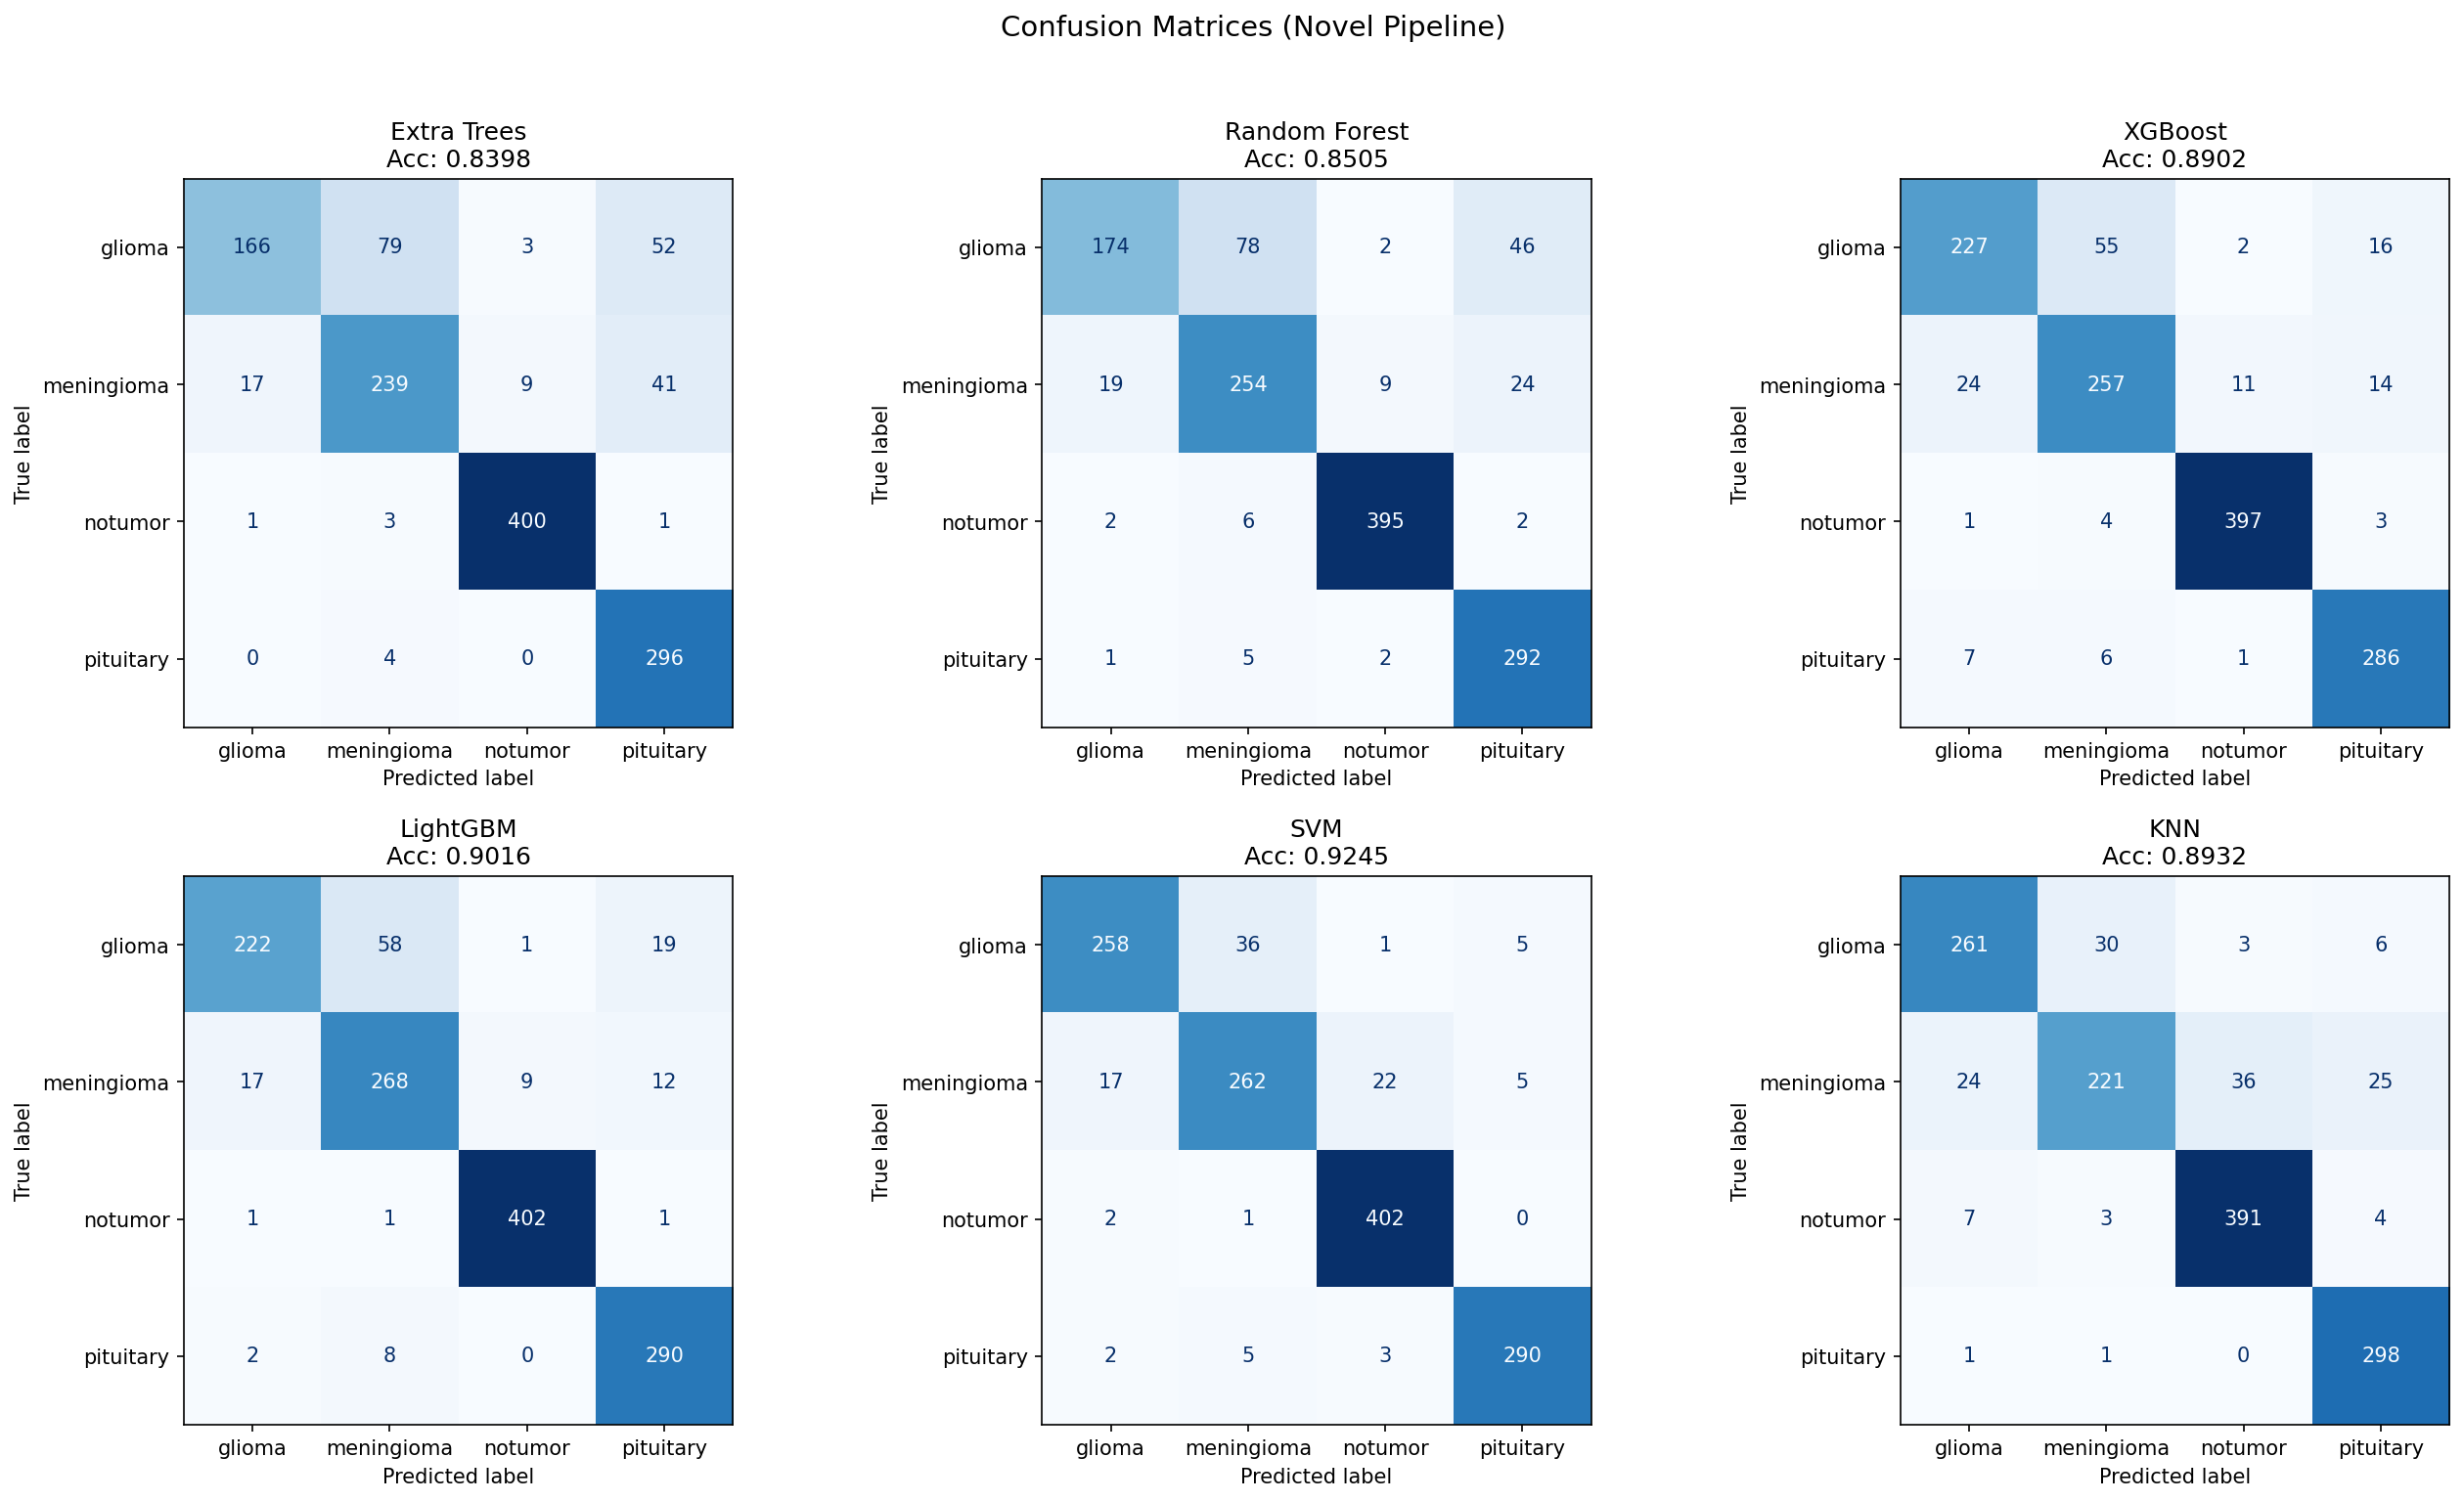

model_comparison_(novel_pipeline).png


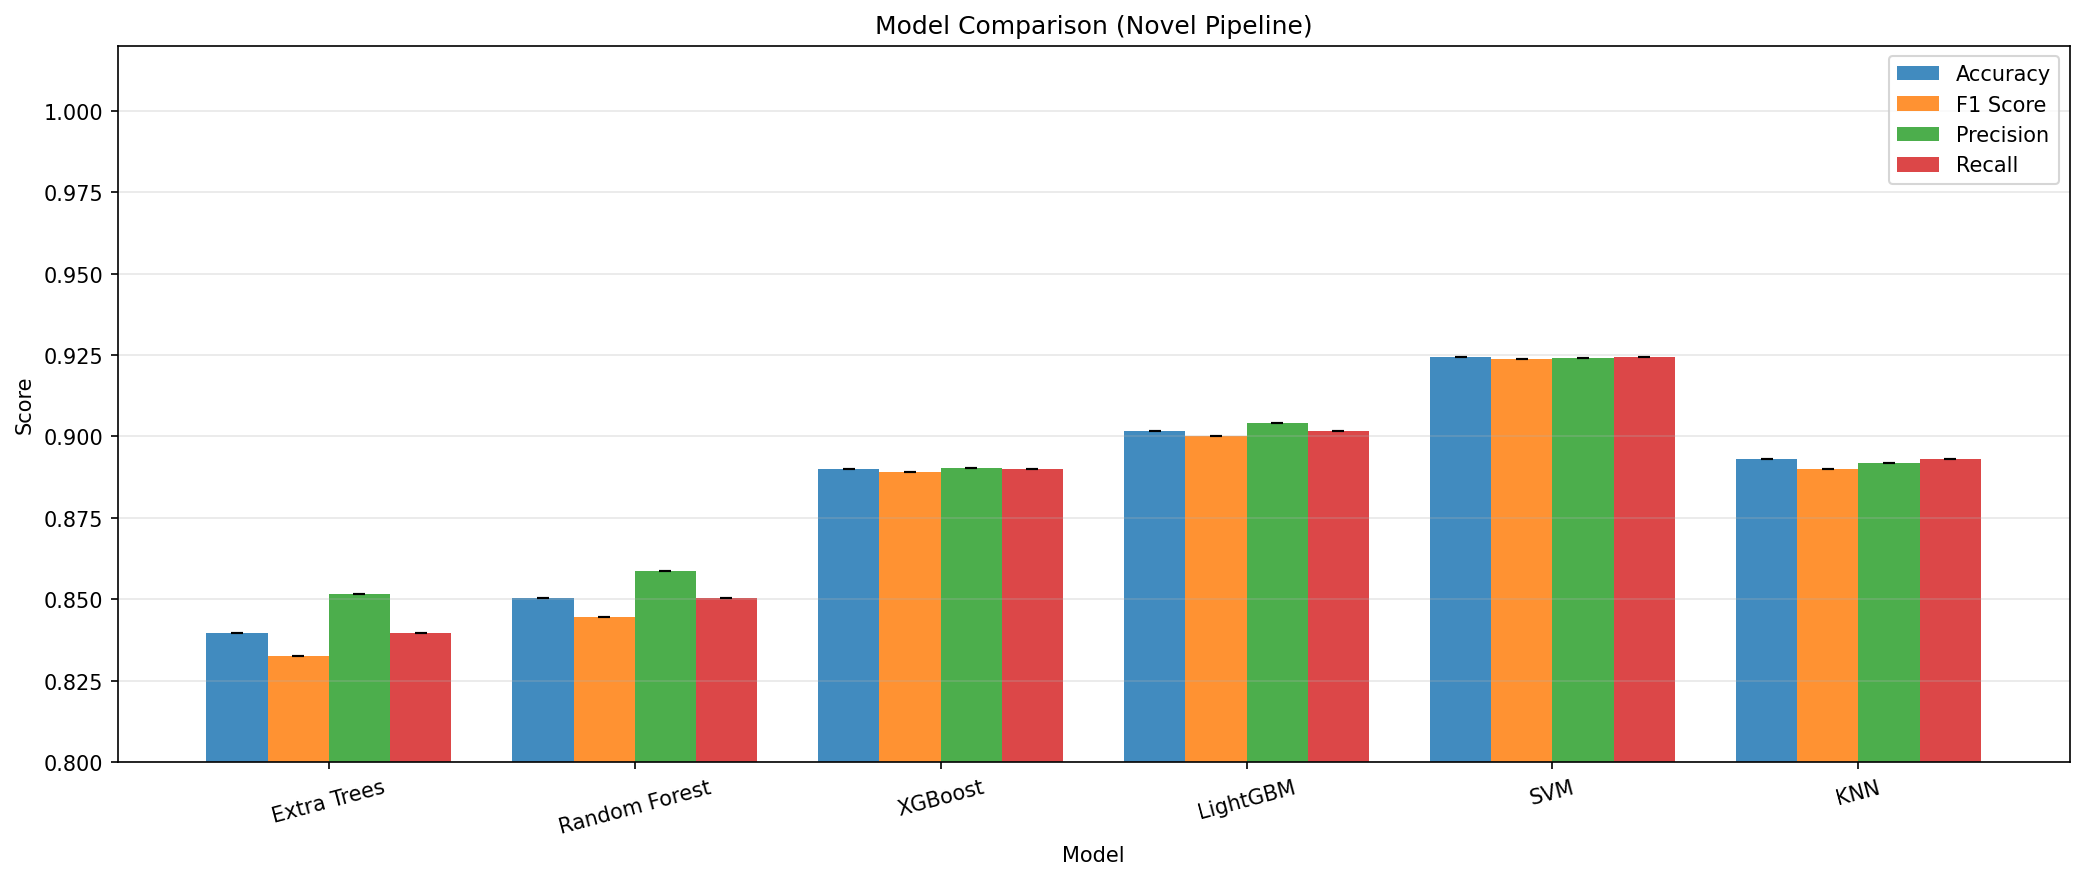

In [19]:
from pathlib import Path
from IPython.display import Image, display

plots_dir = Path(OUTPUT_DIR) / 'plots'
if not plots_dir.exists():
    print('Plots directory not found yet. Run the pipeline cell first.')
else:
    plot_files = sorted(plots_dir.glob('*.png'))
    if not plot_files:
        print('No plots found yet. Run the pipeline cell first or check for earlier errors.')
    else:
        for image_path in plot_files:
            print(image_path.name)
            display(Image(filename=str(image_path)))


## 16. Final run summary

This section turns the notebook ending into a real completion report. It tells you whether the run succeeded, what artifacts were produced, and what is still missing if the pipeline stopped early.


In [21]:
import json
from pathlib import Path

output_dir = Path(OUTPUT_DIR)
metrics_dir = output_dir / 'metrics'
plots_dir = output_dir / 'plots'
ablation_dir = output_dir / 'ablation'

expected_metrics = [
    'full_results.json',
    'ablation_results.json',
    'roi_evaluation.json',
    'roi_explainability_alignment.json',
]

existing_metrics = sorted(p.name for p in metrics_dir.glob("*.json")) if metrics_dir.exists() else []
missing_metrics = [name for name in expected_metrics if name not in existing_metrics]
plot_files = sorted(p.name for p in plots_dir.glob("*.png")) if plots_dir.exists() else []

summary = {
    'pipeline_completed': globals().get('PIPELINE_COMPLETED', False),
    'pipeline_error': None if globals().get('PIPELINE_ERROR') is None else repr(globals().get('PIPELINE_ERROR')),
    'primary_dataset_base': os.environ.get('BRAIN_TUMOR_DATASET_BASE'),
    'secondary_dataset_base': os.environ.get('BRAIN_TUMOR_SECONDARY_DATASET_BASE'),
    'output_dir_exists': output_dir.exists(),
    'metrics_found': existing_metrics,
    'missing_expected_metrics': missing_metrics,
    'num_plots': len(plot_files),
    'plot_files': plot_files,
}

full_results_path = metrics_dir / "full_results.json"
if full_results_path.exists():
    with full_results_path.open() as f:
        full_results = json.load(f)
    summary.update({
        'best_model': full_results.get('best_model'),
        'cnn_accuracy': (full_results.get('cnn_results') or {}).get('metrics', {}).get('accuracy'),
        'cross_dataset_present': full_results.get('cross_dataset_generalization') is not None,
        'tensor_network_methods': list((full_results.get('tensor_network_benchmark') or {}).keys()),
        'total_time_formatted': full_results.get('total_time_formatted'),
    })

summary


{'pipeline_completed': True,
 'pipeline_error': None,
 'primary_dataset_base': '/kaggle/input/datasets/usable1234/brain-tumor-dataset-apr-7/Dataset',
 'secondary_dataset_base': None,
 'output_dir_exists': True,
 'metrics_found': ['full_results.json', 'roi_evaluation.json'],
 'missing_expected_metrics': ['ablation_results.json',
  'roi_explainability_alignment.json'],
 'num_plots': 2,
 'plot_files': ['confusion_matrices_(novel_pipeline).png',
  'model_comparison_(novel_pipeline).png'],
 'best_model': 'SVM',
 'cnn_accuracy': None,
 'cross_dataset_present': False,
 'tensor_network_methods': [],
 'total_time_formatted': '00:14:14'}

## 17. Artifact inventory

This gives you a file-by-file list of generated outputs so the notebook ends with a concrete deliverable inventory.


In [22]:
from pathlib import Path

output_dir = Path(OUTPUT_DIR)
if not output_dir.exists():
    print('Output directory not found yet. Run the pipeline cell first.')
else:
    all_files = sorted(p for p in output_dir.rglob("*") if p.is_file())
    if not all_files:
        print('No output files found yet. Run the pipeline cell first or inspect earlier errors.')
    else:
        for file_path in all_files:
            size_kb = file_path.stat().st_size / 1024
            print(f"{file_path.relative_to(output_dir)} ({size_kb:.1f} KB)")


metrics/full_results.json (6.9 KB)
metrics/roi_evaluation.json (0.8 KB)
metrics/roi_test.npy (80017.2 KB)
metrics/roi_train.npy (348632.9 KB)
metrics/tda_test.npy (2253.4 KB)
metrics/tda_train.npy (9817.6 KB)
plots/confusion_matrices_(novel_pipeline).png (150.6 KB)
plots/model_comparison_(novel_pipeline).png (69.9 KB)


## 18. Package outputs for download

This final step creates a single archive you can download from Kaggle after the run completes.


In [23]:
import shutil
from pathlib import Path

output_dir = Path(OUTPUT_DIR)
archive_base = "/kaggle/working/brain_tumor_topology_outputs"
if not output_dir.exists() or not any(output_dir.rglob("*")):
    print('Nothing to archive yet. Run the pipeline first.')
else:
    archive_path = shutil.make_archive(archive_base, "zip", output_dir)
    print('Created archive:', archive_path)


Created archive: /kaggle/working/brain_tumor_topology_outputs.zip


## 19. Notebook complete

If the pipeline ran successfully, you should now have:

- metrics JSON files in `/kaggle/working/output/metrics`
- plots in `/kaggle/working/output/plots`
- a zipped archive in `/kaggle/working/brain_tumor_topology_outputs.zip`

Recommended Kaggle workflow after this point:

1. Open the metric JSON files and verify the best model / CNN metrics.
2. Download the generated ZIP archive if you want all outputs at once.
3. Save a notebook version or commit the Kaggle notebook once the run looks correct.


In [24]:
from pathlib import Path

archive_path = Path("/kaggle/working/brain_tumor_topology_outputs.zip")
print("PIPELINE_COMPLETED =", globals().get("PIPELINE_COMPLETED", False))
print("ARCHIVE_EXISTS =", archive_path.exists())
print("ARCHIVE_PATH =", archive_path)
if globals().get("PIPELINE_ERROR") is not None:
    print("PIPELINE_ERROR =", repr(globals()["PIPELINE_ERROR"]))
elif not globals().get("PIPELINE_COMPLETED", False):
    print("Run Section 13 first, then rerun the final sections.")
else:
    print("Notebook completed successfully.")


PIPELINE_COMPLETED = True
ARCHIVE_EXISTS = True
ARCHIVE_PATH = /kaggle/working/brain_tumor_topology_outputs.zip
Notebook completed successfully.


In [30]:
import joblib
import torch
from pathlib import Path

output_dir = Path(OUTPUT_DIR)
models_dir = output_dir / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

all_results_from_main = globals().get('all_classical_models_global')
cnn_results_from_main = globals().get('cnn_model_output_global')

saved_files = []

# Save all classical models already in memory
if all_results_from_main is not None:
    for model_name, result in all_results_from_main.items():
        fitted_model = result.get('fitted_model')
        if fitted_model is not None:
            model_path = models_dir / f"{model_name.replace(' ', '_').replace('/', '_').lower()}.joblib"
            try:
                joblib.dump(fitted_model, model_path)
                saved_files.append(str(model_path))
                print(f"Saved: {model_name} -> {model_path}")
            except Exception as e:
                print(f"Failed to save {model_name}: {e}")
        else:
            print(f"No fitted model found for {model_name}")
else:
    print("No classical models found in memory.")

# Save CNN only if it already exists in memory
if cnn_results_from_main is not None and cnn_results_from_main.get('model') is not None:
    cnn_model_path = models_dir / "cnn_model.pth"
    try:
        torch.save(cnn_results_from_main['model'].state_dict(), cnn_model_path)
        saved_files.append(str(cnn_model_path))
        print(f"Saved CNN model -> {cnn_model_path}")
    except Exception as e:
        print(f"Failed to save CNN model: {e}")
else:
    print("CNN model was not trained in this session, so nothing to save for CNN.")

print("\nSaved files:")
for f in saved_files:
    print(f)

Saved: Extra Trees -> /kaggle/working/output/models/extra_trees.joblib
Saved: Random Forest -> /kaggle/working/output/models/random_forest.joblib
Saved: XGBoost -> /kaggle/working/output/models/xgboost.joblib
Saved: LightGBM -> /kaggle/working/output/models/lightgbm.joblib
Saved: SVM -> /kaggle/working/output/models/svm.joblib
Saved: KNN -> /kaggle/working/output/models/knn.joblib
CNN model was not trained in this session, so nothing to save for CNN.

Saved files:
/kaggle/working/output/models/extra_trees.joblib
/kaggle/working/output/models/random_forest.joblib
/kaggle/working/output/models/xgboost.joblib
/kaggle/working/output/models/lightgbm.joblib
/kaggle/working/output/models/svm.joblib
/kaggle/working/output/models/knn.joblib


In [25]:
import joblib
import torch
from pathlib import Path

output_dir = Path(OUTPUT_DIR)
models_dir = output_dir / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

# Access the models from the global variables populated by the main() function
# (These global variables are set in cell f284b120)
all_results_from_main = globals().get('all_classical_models_global')
cnn_results_from_main = globals().get('cnn_model_output_global')

# Retrieve best model name from full_results.json if it's available
full_results_path = output_dir / 'metrics' / 'full_results.json'
best_model_name = None
if full_results_path.exists():
    try:
        with full_results_path.open() as f:
            full_results_json = json.load(f)
        best_model_name = full_results_json.get('best_model')
    except Exception as e:
        print(f"Error loading full_results.json: {e}")

# Save the best classical model
if all_results_from_main is not None and best_model_name and best_model_name in all_results_from_main:
    best_classical_model_obj = all_results_from_main[best_model_name].get('fitted_model')
    if best_classical_model_obj is not None:
        classical_model_path = models_dir / f"{best_model_name.replace(' ', '_').lower()}.joblib"
        try:
            joblib.dump(best_classical_model_obj, classical_model_path)
            print(f"Saved best classical model '{best_model_name}' to {classical_model_path}")
        except Exception as e:
            print(f"Error saving classical model: {e}")
    else:
        print(f"Fitted model for '{best_model_name}' not found in results.")
else:
    print("Classical models not available or best model not identified.")

# Save the CNN model
if cnn_results_from_main is not None and cnn_results_from_main.get('model') is not None:
    cnn_model_obj = cnn_results_from_main['model']
    cnn_model_path = models_dir / "cnn_model.pth"
    try:
        torch.save(cnn_model_obj.state_dict(), cnn_model_path)
        print(f"Saved CNN model to {cnn_model_path}")
    except Exception as e:
        print(f"Error saving CNN model: {e}")
else:
    print("CNN model object not available to save.")

print("Saved models are now included in the final archive.")


Saved best classical model 'SVM' to /kaggle/working/output/models/svm.joblib
CNN model object not available to save.
Saved models are now included in the final archive.


In [31]:
import shutil

shutil.make_archive('/kaggle/working/full_working_dir', 'zip', '/kaggle/working')

'/kaggle/working/full_working_dir.zip'

In [32]:
from IPython.display import FileLink

FileLink('/kaggle/working/full_working_dir.zip')

/kaggle/working/full_working_dir.zip

In [33]:
import os
import zipfile
import joblib

# folder where all saved models will go
SAVE_DIR = "/kaggle/working/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Models will be saved in:", SAVE_DIR)

Models will be saved in: /kaggle/working/saved_models
